In [1]:
# ============================================================================
# DEPENDENCY INSTALLATION 
# ============================================================================

# Install required libraries (run only once)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm prophet plotly jupyter


📊 EXPLORATORY ANALYSIS - VODAFONE BRAGA PARQUE
📈 Dataset loaded: 3,833 total records
📈 Days with sales: 3,812 records
📅 Period: 2015-01-02 to 2025-06-29
💰 Total revenue: €89,590,080

📊 DESCRIPTIVE STATISTICS

Daily Sales:
  • Mean: €23,502
  • Median: €22,941
  • Min: €13,701
  • Max: €48,409
  • Std Dev: €4,359

Daily Profit:
  • Mean: €5,575
  • Median: €5,443
  • Min: €2,235
  • Max: €13,179
  • Average Margin: 23.7%


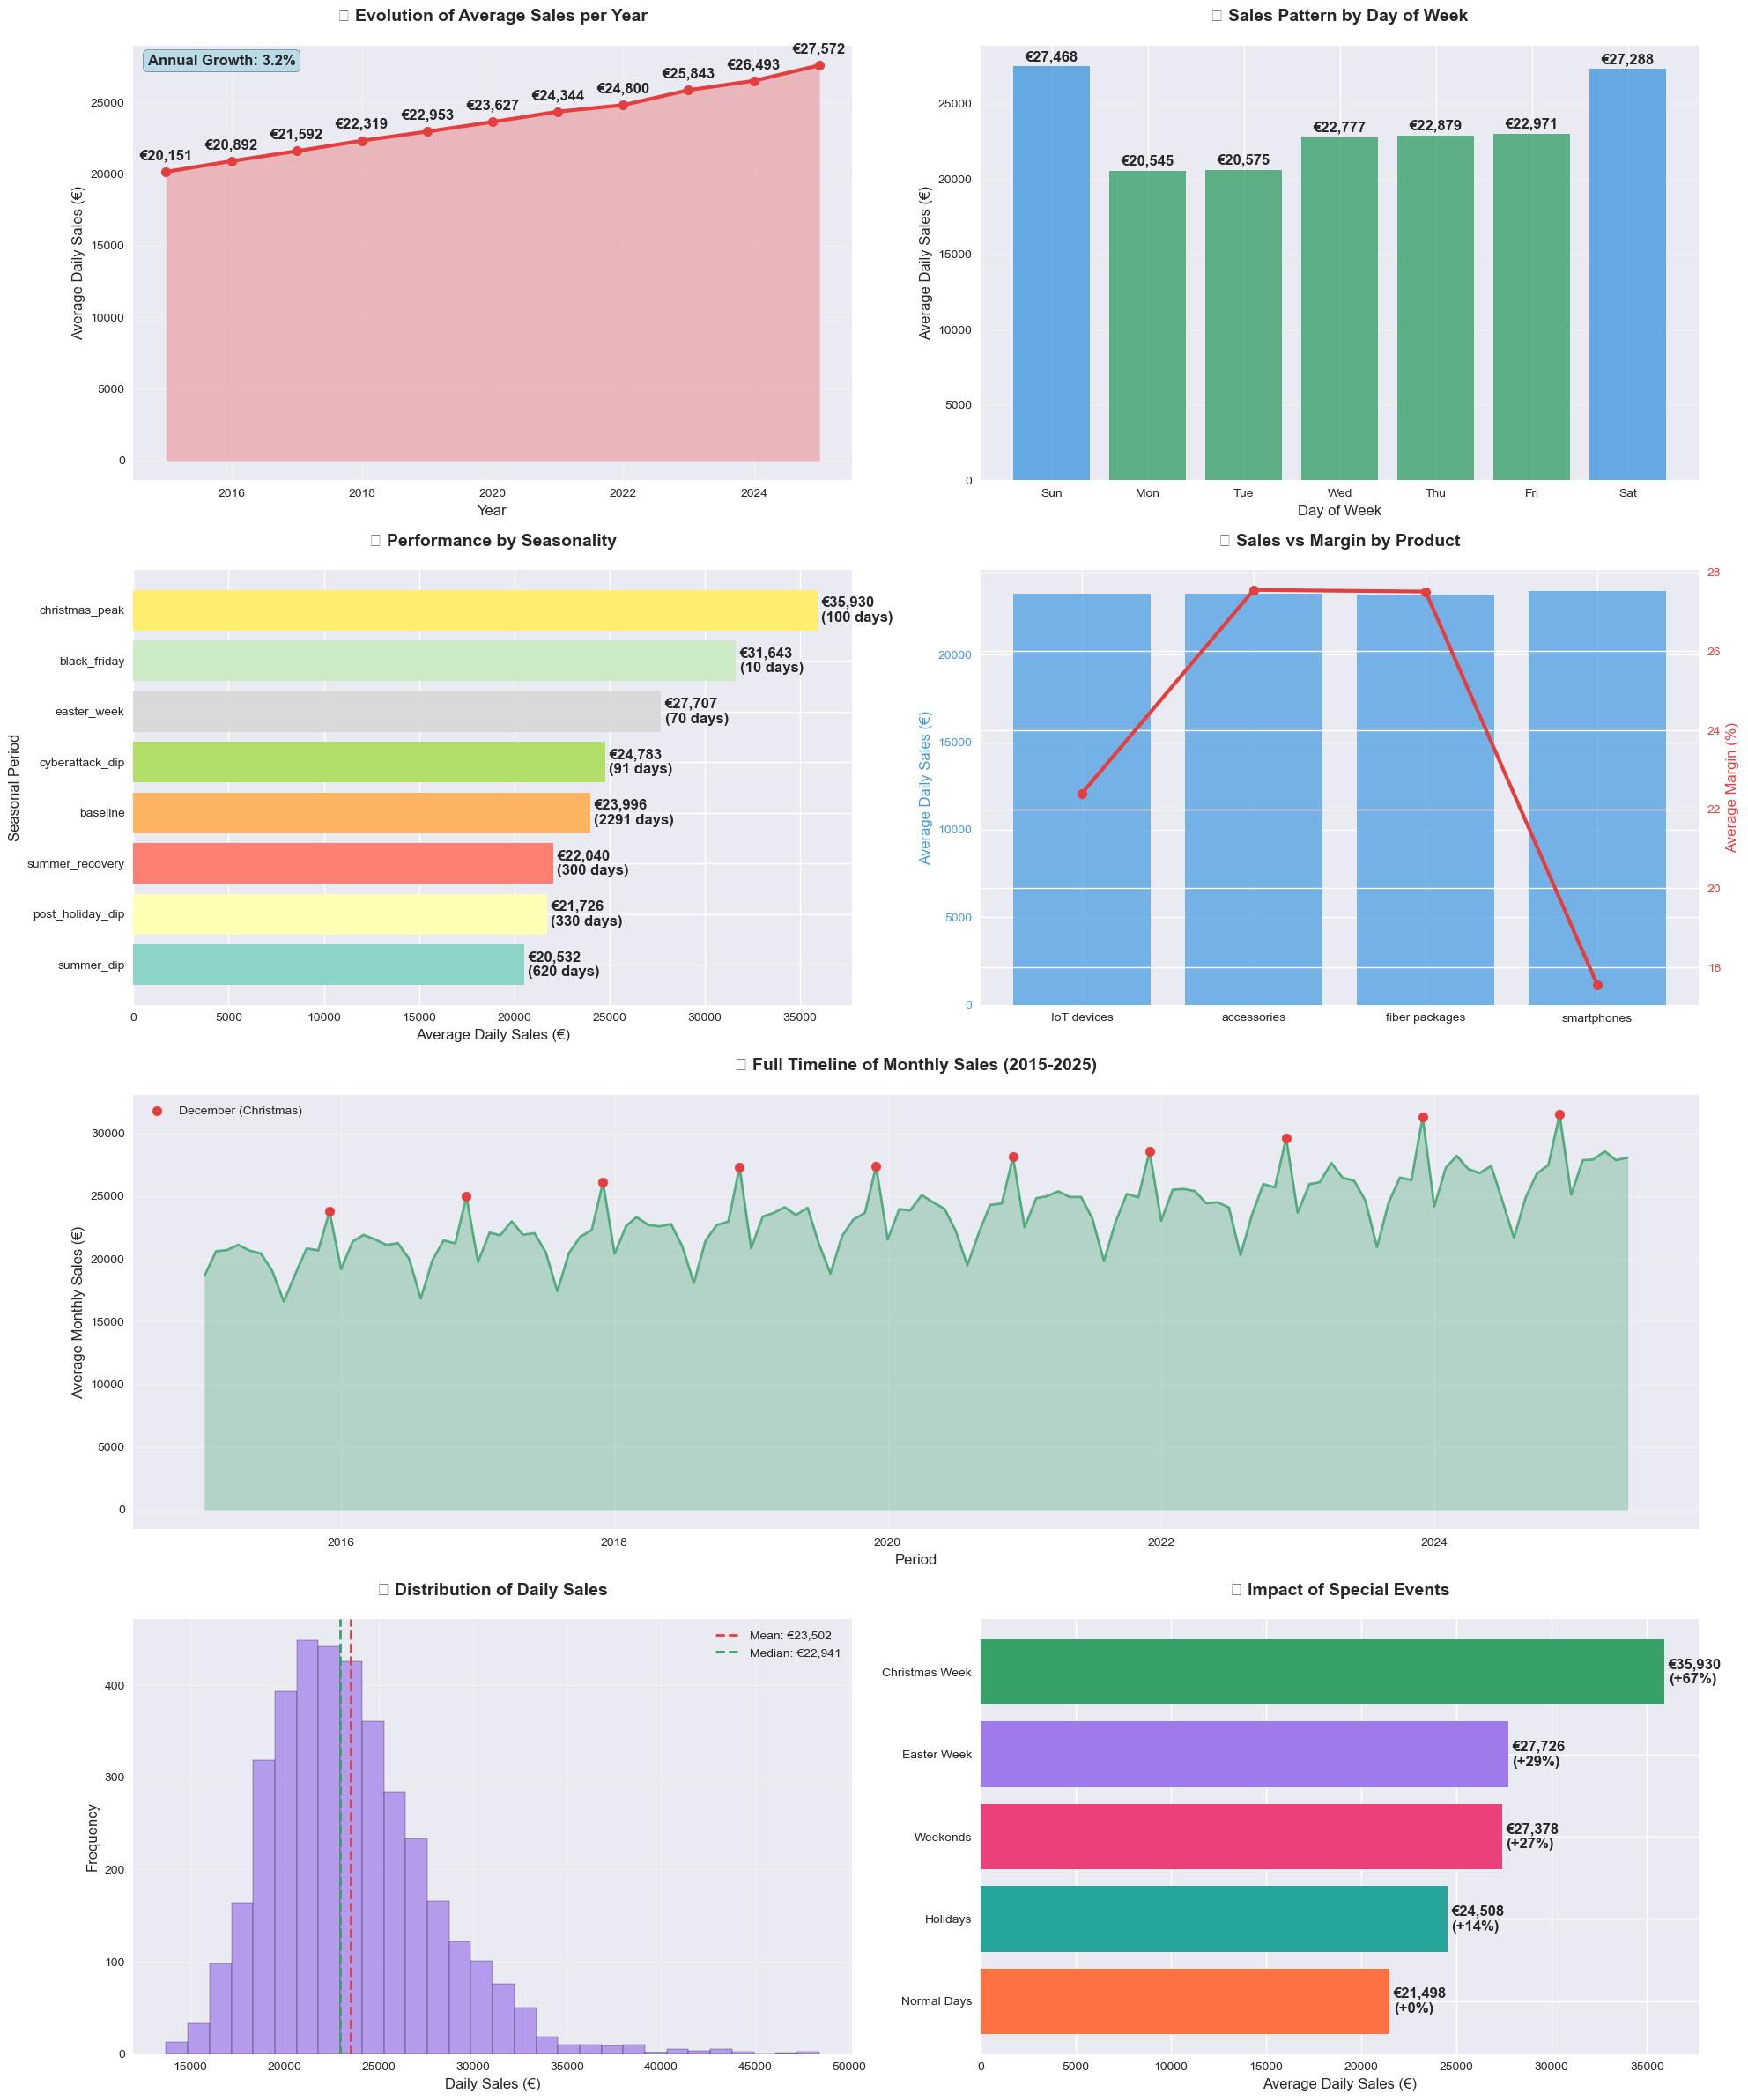


🔍 KEY INSIGHTS FOR VODAFONE MANAGEMENT
 1. 🎄 CHRISTMAS EFFECT: Sales rise 67% during Christmas week
 2. 📅 WEEKEND BOOST: Weekends generate 25% more sales than weekdays
 3. 📈 SUSTAINED GROWTH: Average annual rate of 3.2% (2015-2025)
 4. 💰 BEST PRODUCT: Accessories with a margin of 27.6%
 5. 🎯 OPPORTUNITY: Mondays and Tuesdays have lower performance — potential for promotions
 6. 💵 TOTAL VOLUME: €89.6M in analyzed revenue
 7. ⚡ HISTORICAL PEAK: €48,409 in daily sales
 8. 📊 CONSISTENCY: Average margin of 23.7% over 11 years

✅ EXPLORATORY ANALYSIS COMPLETE
📊 Dataset prepared for Machine Learning modeling

📋 EXECUTIVE SUMMARY:
• Period analyzed: 3,812 days of sales (2015-2025)
• Average daily revenue: €23,502
• Annual growth: 3.2%
• Average margin: 23.7%
• Biggest opportunity: Optimization of seasonal events (+67% at Christmas)

💾 Processed data saved to 'vodafone_sales_processed.csv'


In [2]:
# ============================================================================
# EXPLORATORY SALES ANALYSIS - VODAFONE BRAGA PARQUE
# Dataset: 2015-2025 | Goal: Sales Forecasting Model
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib for better visualization
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("📊 EXPLORATORY ANALYSIS - VODAFONE BRAGA PARQUE")
print("=" * 60)

# ============================================================================
# 1. DATA LOADING AND CLEANING
# ============================================================================

# Load dataset
df = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vendas_loja_vodafone_braga.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Filter only days with sales (remove closed days)
df_sales = df[df['daily_sales'] > 0].copy()

# Add temporal features
df_sales['year'] = df_sales['date'].dt.year
df_sales['month'] = df_sales['date'].dt.month
df_sales['quarter'] = df_sales['date'].dt.quarter

print(f"📈 Dataset loaded: {len(df):,} total records")
print(f"📈 Days with sales: {len(df_sales):,} records")
print(f"📅 Period: {df_sales['date'].min().strftime('%Y-%m-%d')} to {df_sales['date'].max().strftime('%Y-%m-%d')}")
print(f"💰 Total revenue: €{df_sales['daily_sales'].sum():,.0f}")

# ============================================================================
# 2. KEY DESCRIPTIVE STATISTICS
# ============================================================================

print("\n" + "=" * 60)
print("📊 DESCRIPTIVE STATISTICS")
print("=" * 60)

# Main statistics
stats = {
    'Daily Sales': {
        'Mean': f"€{df_sales['daily_sales'].mean():,.0f}",
        'Median': f"€{df_sales['daily_sales'].median():,.0f}",
        'Min': f"€{df_sales['daily_sales'].min():,.0f}",
        'Max': f"€{df_sales['daily_sales'].max():,.0f}",
        'Std Dev': f"€{df_sales['daily_sales'].std():,.0f}"
    },
    'Daily Profit': {
        'Mean': f"€{df_sales['daily_profit'].mean():,.0f}",
        'Median': f"€{df_sales['daily_profit'].median():,.0f}",
        'Min': f"€{df_sales['daily_profit'].min():,.0f}",
        'Max': f"€{df_sales['daily_profit'].max():,.0f}",
        'Average Margin': f"{(df_sales['daily_profit'].sum() / df_sales['daily_sales'].sum() * 100):.1f}%"
    }
}

for category, values in stats.items():
    print(f"\n{category}:")
    for metric, value in values.items():
        print(f"  • {metric}: {value}")

# ============================================================================
# 3. MAIN VISUALIZATIONS
# ============================================================================

# Create figure with subplots
fig = plt.figure(figsize=(20, 24))

# 3.1 YEARLY SALES EVOLUTION
plt.subplot(4, 2, 1)
yearly_data = df_sales.groupby('year')['daily_sales'].agg(['mean', 'sum']).reset_index()
yearly_data['mean'] = yearly_data['mean'].round(0)

plt.plot(yearly_data['year'], yearly_data['mean'], marker='o', linewidth=3, markersize=8, color='#e53e3e')
plt.fill_between(yearly_data['year'], yearly_data['mean'], alpha=0.3, color='#e53e3e')
plt.title('📈 Evolution of Average Sales per Year', fontweight='bold', pad=20)
plt.xlabel('Year')
plt.ylabel('Average Daily Sales (€)')
plt.grid(True, alpha=0.3)

# Add values on points
for i, row in yearly_data.iterrows():
    plt.annotate(f'€{row["mean"]:,.0f}', 
                (row['year'], row['mean']), 
                textcoords="offset points", 
                xytext=(0,10), ha='center', fontweight='bold')

# Compute annual growth
first_year_avg = yearly_data.iloc[0]['mean']
last_year_avg = yearly_data.iloc[-1]['mean']
years_diff = yearly_data.iloc[-1]['year'] - yearly_data.iloc[0]['year']
annual_growth = ((last_year_avg / first_year_avg) ** (1/years_diff) - 1) * 100

plt.text(0.02, 0.98, f'Annual Growth: {annual_growth:.1f}%', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
         verticalalignment='top')

# 3.2 WEEKLY PATTERN
plt.subplot(4, 2, 2)
weekday_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
weekly_data = df_sales.groupby('day_of_week')['daily_sales'].mean().reset_index()
weekly_data['weekday_name'] = [weekday_names[i] for i in weekly_data['day_of_week']]

colors = ['#4299e1' if day in [0, 6] else '#38a169' for day in weekly_data['day_of_week']]
bars = plt.bar(weekly_data['weekday_name'], weekly_data['daily_sales'], color=colors, alpha=0.8)
plt.title('📅 Sales Pattern by Day of Week', fontweight='bold', pad=20)
plt.xlabel('Day of Week')
plt.ylabel('Average Daily Sales (€)')
plt.grid(True, alpha=0.3, axis='y')

# Add values to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
             f'€{height:,.0f}', ha='center', va='bottom', fontweight='bold')

# 3.3 SEASONALITY
plt.subplot(4, 2, 3)
seasonal_data = df_sales.groupby('seasonality')['daily_sales'].agg(['mean', 'count']).reset_index()
seasonal_data = seasonal_data.sort_values('mean', ascending=True)

bars = plt.barh(seasonal_data['seasonality'], seasonal_data['mean'], 
               color=plt.cm.Set3(np.linspace(0, 1, len(seasonal_data))))
plt.title('🎯 Performance by Seasonality', fontweight='bold', pad=20)
plt.xlabel('Average Daily Sales (€)')
plt.ylabel('Seasonal Period')

# Add values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    days = seasonal_data.iloc[i]['count']
    plt.text(width + 200, bar.get_y() + bar.get_height()/2,
             f'€{width:,.0f}\n({days} days)', 
             ha='left', va='center', fontweight='bold')

# 3.4 PERFORMANCE BY PRODUCT
plt.subplot(4, 2, 4)
product_data = df_sales.groupby('top_product').agg({
    'daily_sales': 'mean',
    'avg_margin': 'mean',
    'date': 'count'
}).reset_index()
product_data.columns = ['product', 'avg_sales', 'avg_margin_val', 'days']
product_data['margin_pct'] = product_data['avg_margin_val'] * 100

# Bar chart with secondary Y axis
ax1 = plt.gca()
bars = ax1.bar(product_data['product'], product_data['avg_sales'], 
               color='#4299e1', alpha=0.7, label='Average Sales')
ax1.set_ylabel('Average Daily Sales (€)', color='#4299e1')
ax1.tick_params(axis='y', labelcolor='#4299e1')

ax2 = ax1.twinx()
line = ax2.plot(product_data['product'], product_data['margin_pct'], 
                color='#e53e3e', marker='o', linewidth=3, markersize=8, label='Margin %')
ax2.set_ylabel('Average Margin (%)', color='#e53e3e')
ax2.tick_params(axis='y', labelcolor='#e53e3e')

plt.title('📱 Sales vs Margin by Product', fontweight='bold', pad=20)
plt.xticks(rotation=45)

# 3.5 FULL MONTHLY TIMELINE
plt.subplot(4, 1, 3)
df_sales['year_month'] = df_sales['date'].dt.to_period('M')
monthly_data = df_sales.groupby('year_month')['daily_sales'].mean().reset_index()
monthly_data['date'] = monthly_data['year_month'].dt.to_timestamp()

plt.plot(monthly_data['date'], monthly_data['daily_sales'], 
         linewidth=2, color='#38a169', alpha=0.8)
plt.fill_between(monthly_data['date'], monthly_data['daily_sales'], 
                alpha=0.3, color='#38a169')

# Highlight important events
christmas_months = monthly_data[monthly_data['date'].dt.month == 12]
plt.scatter(christmas_months['date'], christmas_months['daily_sales'], 
           color='#e53e3e', s=60, zorder=5, label='December (Christmas)')

plt.title('📊 Full Timeline of Monthly Sales (2015-2025)', fontweight='bold', pad=20)
plt.xlabel('Period')
plt.ylabel('Average Monthly Sales (€)')
plt.grid(True, alpha=0.3)
plt.legend()

# 3.6 DISTRIBUTION OF DAILY SALES
plt.subplot(4, 2, 7)
plt.hist(df_sales['daily_sales'], bins=30, alpha=0.7, color='#9f7aea', edgecolor='black')
plt.axvline(df_sales['daily_sales'].mean(), color='#e53e3e', linestyle='--', 
            linewidth=2, label=f'Mean: €{df_sales["daily_sales"].mean():,.0f}')
plt.axvline(df_sales['daily_sales'].median(), color='#38a169', linestyle='--', 
            linewidth=2, label=f'Median: €{df_sales["daily_sales"].median():,.0f}')
plt.title('💰 Distribution of Daily Sales', fontweight='bold', pad=20)
plt.xlabel('Daily Sales (€)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 3.7 SPECIAL EVENTS COMPARISON
plt.subplot(4, 2, 8)
events_comparison = {
    'Christmas Week': df_sales[df_sales['is_christmas_week'] == 1]['daily_sales'].mean(),
    'Easter Week': df_sales[df_sales['is_easter_week'] == 1]['daily_sales'].mean(),
    'Weekends': df_sales[df_sales['is_weekend'] == 1]['daily_sales'].mean(),
    'Holidays': df_sales[df_sales['is_holiday'] == 1]['daily_sales'].mean(),
    'Normal Days': df_sales[(df_sales['is_christmas_week'] == 0) & 
                           (df_sales['is_easter_week'] == 0) & 
                           (df_sales['is_weekend'] == 0) & 
                           (df_sales['is_holiday'] == 0)]['daily_sales'].mean()
}

events_df = pd.DataFrame(list(events_comparison.items()), columns=['Event', 'Average_Sales'])
events_df = events_df.sort_values('Average_Sales', ascending=True)

bars = plt.barh(events_df['Event'], events_df['Average_Sales'], 
               color=['#ff7043', '#26a69a', '#ec407a', '#9f7aea', '#38a169'])
plt.title('🎄 Impact of Special Events', fontweight='bold', pad=20)
plt.xlabel('Average Daily Sales (€)')

# Add values and % vs normal
normal_avg = events_comparison['Normal Days']
for i, bar in enumerate(bars):
    width = bar.get_width()
    pct_diff = ((width / normal_avg) - 1) * 100
    plt.text(width + 200, bar.get_y() + bar.get_height()/2,
             f'€{width:,.0f}\n({pct_diff:+.0f}%)', 
             ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================================
# 4. KEY INSIGHTS FOR PRESENTATION
# ============================================================================

print("\n" + "=" * 60)
print("🔍 KEY INSIGHTS FOR VODAFONE MANAGEMENT")
print("=" * 60)

# Compute specific insights
christmas_avg = df_sales[df_sales['is_christmas_week'] == 1]['daily_sales'].mean()
normal_avg = df_sales[(df_sales['is_christmas_week'] == 0) & 
                     (df_sales['is_easter_week'] == 0) & 
                     (df_sales['is_weekend'] == 0) & 
                     (df_sales['is_holiday'] == 0)]['daily_sales'].mean()

weekend_avg = df_sales[df_sales['is_weekend'] == 1]['daily_sales'].mean()
weekday_avg = df_sales[df_sales['is_weekend'] == 0]['daily_sales'].mean()

# Top product by margin
product_margins = df_sales.groupby('top_product')['avg_margin'].mean().sort_values(ascending=False)
best_margin_product = product_margins.index[0]
best_margin_value = product_margins.iloc[0] * 100

insights = [
    f"🎄 CHRISTMAS EFFECT: Sales rise {((christmas_avg/normal_avg - 1) * 100):.0f}% during Christmas week",
    f"📅 WEEKEND BOOST: Weekends generate {((weekend_avg/weekday_avg - 1) * 100):.0f}% more sales than weekdays",
    f"📈 SUSTAINED GROWTH: Average annual rate of {annual_growth:.1f}% (2015-2025)",
    f"💰 BEST PRODUCT: {best_margin_product.title()} with a margin of {best_margin_value:.1f}%",
    f"🎯 OPPORTUNITY: Mondays and Tuesdays have lower performance — potential for promotions",
    f"💵 TOTAL VOLUME: €{df_sales['daily_sales'].sum() / 1000000:.1f}M in analyzed revenue",
    f"⚡ HISTORICAL PEAK: €{df_sales['daily_sales'].max():,.0f} in daily sales",
    f"📊 CONSISTENCY: Average margin of {(df_sales['daily_profit'].sum() / df_sales['daily_sales'].sum() * 100):.1f}% over 11 years"
]

for i, insight in enumerate(insights, 1):
    print(f"{i:2d}. {insight}")

print(f"\n{'='*60}")
print("✅ EXPLORATORY ANALYSIS COMPLETE")
print("📊 Dataset prepared for Machine Learning modeling")
print(f"{'='*60}")

# ============================================================================
# 5. EXECUTIVE SUMMARY FOR PRESENTATION
# ============================================================================

print("\n📋 EXECUTIVE SUMMARY:")
print(f"• Period analyzed: {len(df_sales):,} days of sales (2015-2025)")
print(f"• Average daily revenue: €{df_sales['daily_sales'].mean():,.0f}")
print(f"• Annual growth: {annual_growth:.1f}%")
print(f"• Average margin: {(df_sales['daily_profit'].sum() / df_sales['daily_sales'].sum() * 100):.1f}%")
print(f"• Biggest opportunity: Optimization of seasonal events (+{((christmas_avg/normal_avg - 1) * 100):.0f}% at Christmas)")

# Save processed data for next steps
df_sales.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vodafone_sales_processed.csv", index=False)
print(f"\n💾 Processed data saved to 'vodafone_sales_processed.csv'")


In [3]:
# ============================================================================
# CLEAN FEATURE ENGINEERING - VODAFONE BRAGA PARQUE
# Goal: Strong seasonal features WITHOUT data leakage + realistic performance
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFE, SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings('ignore')

print("🔧 CLEAN FEATURE ENGINEERING - NO DATA LEAKAGE")
print("🎯 Focus: Strong seasonality + Realistic performance")
print("=" * 70)

# ============================================================================
# 1. DATA LOADING
# ============================================================================

# Load processed data from exploratory analysis
df = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vodafone_sales_processed.csv")
df['date'] = pd.to_datetime(df['date'])

# Load future holidays
holidays_future = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\feriados_braga_2026_2027.csv")
holidays_future['date'] = pd.to_datetime(holidays_future['date'])

print(f"📈 Data loaded: {len(df):,} records")
print(f"🎄 Future holidays: {len(holidays_future):,} records (2026-2027)")
print(f"📅 Full period: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")

# ============================================================================
# 2. CLEAN FEATURE ENGINEERING - ZERO DATA LEAKAGE
# ============================================================================

print("\n" + "=" * 70)
print("🔧 CREATING CLEAN FEATURES WITHOUT DATA LEAKAGE")
print("=" * 70)

def create_clean_temporal_features(df):
    """Create clean temporal features (not using target)"""
    df = df.copy()
    
    print("🔄 Creating basic temporal features...")
    
    # ==================== BASIC TEMPORAL FEATURES ====================
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week
    
    # ==================== ENHANCED CYCLICAL ENCODING ====================
    print("🔄 Creating cyclical encoding...")
    
    # Day of year (1-365/366) - CRITICAL FOR SEASONALITY
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    
    # Month (1-12) - ESSENTIAL FOR MONTHLY PATTERNS
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Day of week (0-6)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # Week of year (1-52)
    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
    
    # ==================== CONSERVATIVE TREND FEATURES ====================
    print("🔄 Creating trend features...")
    
    # Days since start (linear trend)
    df['days_since_start'] = (df['date'] - df['date'].min()).dt.days
    
    # Conservative yearly trend (1.5% per year)
    df['yearly_trend'] = (df['year'] - df['year'].min()) * 0.015
    
    return df

def create_clean_seasonal_features(df):
    """Create clean seasonal features based only on calendar"""
    df = df.copy()
    
    print("🔄 Creating clean seasonal features...")
    
    # ==================== PROXIMITY TO FIXED EVENTS ====================
    
    def days_to_christmas(date):
        """Days until next Christmas"""
        year = date.year
        christmas = pd.Timestamp(f"{year}-12-25")
        if date > christmas:
            christmas = pd.Timestamp(f"{year + 1}-12-25")
        return (christmas - date).days
    
    def days_to_easter(date):
        """Days until next Easter (approximation)"""
        year = date.year
        easter_approx = pd.Timestamp(f"{year}-04-08")
        if date > easter_approx:
            easter_approx = pd.Timestamp(f"{year + 1}-04-08")
        return (easter_approx - date).days
    
    def days_to_summer_peak(date):
        """Days until summer peak (August 15)"""
        year = date.year
        summer_peak = pd.Timestamp(f"{year}-08-15")
        if date.month >= 10:  # After September
            summer_peak = pd.Timestamp(f"{year + 1}-08-15")
        return abs((summer_peak - date).days)
    
    df['days_to_christmas'] = df['date'].apply(days_to_christmas)
    df['days_to_easter'] = df['date'].apply(days_to_easter)
    df['days_to_summer_peak'] = df['date'].apply(days_to_summer_peak)
    
    # Exponential proximities
    df['christmas_proximity'] = np.exp(-df['days_to_christmas'] / 30)
    df['easter_proximity'] = np.exp(-df['days_to_easter'] / 20)
    df['summer_proximity'] = np.exp(-df['days_to_summer_peak'] / 45)
    
    # ==================== SEASONAL INDICATORS ====================
    
    # Season indicators based on month
    df['is_summer'] = df['month'].isin([7, 8]).astype(int)
    df['is_autumn'] = df['month'].isin([9, 10, 11]).astype(int)
    df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)
    df['is_spring'] = df['month'].isin([3, 4, 5]).astype(int)
    
    # Specific indicators for known patterns
    df['is_july'] = (df['month'] == 7).astype(int)
    df['is_august'] = (df['month'] == 8).astype(int)
    df['is_september'] = (df['month'] == 9).astype(int)
    df['is_october'] = (df['month'] == 10).astype(int)
    df['is_december'] = (df['month'] == 12).astype(int)
    
    return df

def create_clean_lag_features(df, target_col='daily_sales', lags=[7, 14, 30]):
    """Create controlled lag features"""
    df = df.copy().sort_values('date')
    
    print(f"🔄 Creating lags: {lags}...")
    
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    return df

def create_clean_rolling_features(df, target_col='daily_sales', windows=[7, 14, 30]):
    """Create clean rolling statistics features"""
    df = df.copy().sort_values('date')
    
    print(f"🔄 Creating rolling windows: {windows}...")
    
    for window in windows:
        # Moving average
        rolling_mean = df[target_col].rolling(window=window, min_periods=1).mean()
        df[f'{target_col}_rolling_mean_{window}'] = rolling_mean.shift(1)  # SHIFT to avoid leakage
        
        # Moving standard deviation
        rolling_std = df[target_col].rolling(window=window, min_periods=1).std()
        df[f'{target_col}_rolling_std_{window}'] = rolling_std.shift(1)  # SHIFT to avoid leakage
        
    return df

def create_clean_interaction_features(df):
    """Create clean interaction features"""
    df = df.copy()
    
    print("🔄 Creating clean interactions...")
    
    # ==================== SAFE SEASONAL INTERACTIONS ====================
    
    # Weekend x Seasons
    df['weekend_x_summer'] = df['is_weekend'] * df['is_summer']
    df['weekend_x_christmas'] = df['is_weekend'] * df['is_christmas_week']
    df['weekend_x_easter'] = df['is_weekend'] * df['is_easter_week']
    
    # Specific month x Weekend
    df['weekend_x_july'] = df['is_weekend'] * df['is_july']
    df['weekend_x_august'] = df['is_weekend'] * df['is_august']
    df['weekend_x_september'] = df['is_weekend'] * df['is_september']
    df['weekend_x_december'] = df['is_weekend'] * df['is_december']
    
    # Proximities x Weekend
    df['christmas_prox_x_weekend'] = df['christmas_proximity'] * df['is_weekend']
    df['summer_prox_x_weekend'] = df['summer_proximity'] * df['is_weekend']
    
    # Quarter x Day of Week
    df['quarter_x_dow'] = df['quarter'] * df['day_of_week']
    
    # ==================== CLEAN BUSINESS FEATURES ====================
    
    # Staff efficiency (without using target)
    df['staff_on_duty_weekend'] = df['staff_on_duty'] * df['is_weekend']
    df['margin_x_staff'] = df['avg_margin'] * df['staff_on_duty']
    
    # Product encoding
    le_product = LabelEncoder()
    df['product_encoded'] = le_product.fit_transform(df['top_product'])
    df['margin_x_product'] = df['avg_margin'] * df['product_encoded']
    
    return df

def create_historical_seasonal_benchmarks(df):
    """Create seasonal benchmarks based ONLY on past historical data"""
    df = df.copy().sort_values('date')
    
    print("🔄 Creating historical seasonal benchmarks...")
    
    # For each observation, compute historical averages for the same month/quarter/dow
    # using only PRIOR data (expanding window)
    
    df['historical_month_avg'] = np.nan
    df['historical_quarter_avg'] = np.nan
    df['historical_dow_avg'] = np.nan
    
    # Expanding calculation (no data leakage)
    for i in range(len(df)):
        if i < 30:  # First 30 observations = not enough history
            continue
            
        # Historical data up to this date (exclusive)
        historical_data = df.iloc[:i]
        
        current_month = df.iloc[i]['month']
        current_quarter = df.iloc[i]['quarter']
        current_dow = df.iloc[i]['day_of_week']
        
        # Historical averages for the same period
        month_data = historical_data[historical_data['month'] == current_month]
        quarter_data = historical_data[historical_data['quarter'] == current_quarter]
        dow_data = historical_data[historical_data['day_of_week'] == current_dow]
        
        if len(month_data) > 0:
            df.at[df.index[i], 'historical_month_avg'] = month_data['daily_sales'].mean()
        if len(quarter_data) > 0:
            df.at[df.index[i], 'historical_quarter_avg'] = quarter_data['daily_sales'].mean()
        if len(dow_data) > 0:
            df.at[df.index[i], 'historical_dow_avg'] = dow_data['daily_sales'].mean()
    
    # Fill NaN with overall means (conservative)
    overall_mean = df['daily_sales'].mean()
    df['historical_month_avg'].fillna(overall_mean, inplace=True)
    df['historical_quarter_avg'].fillna(overall_mean, inplace=True)
    df['historical_dow_avg'].fillna(overall_mean, inplace=True)
    
    return df

# ============================================================================
# 3. APPLY ALL CLEAN TRANSFORMATIONS
# ============================================================================

print("\n🔄 APPLYING CLEAN FEATURE ENGINEERING:")

# Correct order to avoid dependencies
df_featured = create_clean_temporal_features(df)
df_featured = create_clean_seasonal_features(df_featured)
df_featured = create_clean_lag_features(df_featured)
df_featured = create_clean_rolling_features(df_featured)
df_featured = create_clean_interaction_features(df_featured)
df_featured = create_historical_seasonal_benchmarks(df_featured)

print(f"✅ Features created: {len(df_featured.columns)} total columns")

# Data leakage check
print("\n🔍 DATA LEAKAGE CHECK:")
potential_leakage = []
safe_features = []

for col in df_featured.columns:
    if col in ['date', 'daily_sales', 'daily_profit']:
        continue
    elif 'daily_sales' in col and col != 'daily_sales':
        # Features that use daily_sales but with lag/shift are OK
        if any(keyword in col for keyword in ['lag', 'rolling']):
            safe_features.append(col)
        else:
            potential_leakage.append(col)
    else:
        safe_features.append(col)

print(f"✅ Safe features: {len(safe_features)}")
print(f"⚠️ Potential leakage: {len(potential_leakage)}")
if potential_leakage:
    print(f"   Suspects: {potential_leakage[:5]}...")

# ============================================================================
# 4. CLEAN IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("📊 IMPORTANCE ANALYSIS - CLEAN FEATURES")
print("=" * 70)

# Prepare data for analysis (remove NaN due to lags)
df_analysis = df_featured.dropna().copy()

# Separate features and target
feature_cols = [col for col in df_analysis.columns if col not in ['date', 'daily_sales', 'daily_profit']]
categorical_features = ['top_product', 'seasonality']

# Convert categoricals to numeric
df_numeric = df_analysis.copy()
for col in categorical_features:
    if col in df_numeric.columns:
        le = LabelEncoder()
        df_numeric[col] = le.fit_transform(df_numeric[col])

# Ensure all features are numeric
numeric_feature_cols = []
for col in feature_cols:
    if df_numeric[col].dtype in ['object', 'string']:
        print(f"⚠️ Converting categorical column: {col}")
        le = LabelEncoder()
        df_numeric[col] = le.fit_transform(df_numeric[col].astype(str))
        numeric_feature_cols.append(col)
    elif df_numeric[col].dtype in ['int64', 'float64', 'int32', 'float32']:
        numeric_feature_cols.append(col)
    else:
        print(f"❌ Ignoring column {col} with type {df_numeric[col].dtype}")

X = df_numeric[numeric_feature_cols]
y = df_numeric['daily_sales']

print(f"📈 Samples for analysis: {len(df_analysis):,}")
print(f"🔧 Features to analyze: {len(numeric_feature_cols)}")

def analyze_clean_feature_importance(X, y, feature_names):
    """Analyze importance focusing on balance and without leakage"""
    
    # 1. Correlation with target
    correlations = []
    for col in feature_names:
        corr, _ = pearsonr(X[col], y)
        correlations.append(abs(corr))
    
    # 2. Mutual Information
    mi_scores = mutual_info_regression(X, y, random_state=42)
    
    # 3. Random Forest Feature Importance
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    rf_importance = rf.feature_importances_
    
    # Combine results
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'correlation': correlations,
        'mutual_info': mi_scores,
        'rf_importance': rf_importance
    })
    
    # Categorize features by type
    def categorize_clean_feature(feature_name):
        if any(keyword in feature_name.lower() for keyword in ['lag', 'rolling']):
            return 'temporal'
        elif any(keyword in feature_name.lower() for keyword in 
                ['month', 'season', 'christmas', 'easter', 'summer', 'quarter', 'july', 'august', 'september', 'october', 'december']):
            return 'seasonal'
        elif any(keyword in feature_name.lower() for keyword in ['weekend', 'day_of_week']):
            return 'weekly'
        elif any(keyword in feature_name.lower() for keyword in ['historical']):
            return 'historical'
        else:
            return 'other'
    
    importance_df['category'] = importance_df['feature'].apply(categorize_clean_feature)
    
    # Normalize scores
    importance_df['correlation_norm'] = importance_df['correlation'] / importance_df['correlation'].max()
    importance_df['mutual_info_norm'] = importance_df['mutual_info'] / importance_df['mutual_info'].max()
    importance_df['rf_importance_norm'] = importance_df['rf_importance'] / importance_df['rf_importance'].max()
    
    # Balanced score with boost for seasonal
    seasonal_boost = importance_df['category'].apply(lambda x: 1.2 if x == 'seasonal' else 1.0)
    
    importance_df['composite_score'] = (
        0.25 * importance_df['correlation_norm'] +
        0.35 * importance_df['mutual_info_norm'] +
        0.4 * importance_df['rf_importance_norm']
    ) * seasonal_boost
    
    return importance_df.sort_values('composite_score', ascending=False)

# Run clean analysis
importance_results = analyze_clean_feature_importance(X, y, numeric_feature_cols)

print("\n🏆 TOP 20 CLEAN FEATURES:")
print("-" * 70)
print(f"{'Feature':<35} {'Category':<12} {'Score':<8} {'Type'}")
print("-" * 70)

for i, row in importance_results.head(20).iterrows():
    category_emoji = {'temporal': '⏰', 'seasonal': '🌞', 'weekly': '📅', 'historical': '📊', 'other': '🔧'}
    emoji = category_emoji.get(row['category'], '❓')
    print(f"{row['feature']:<35} {row['category']:<12} {row['composite_score']:<7.3f} {emoji}")

# Balance analysis
print(f"\n📊 BALANCE ANALYSIS BY CATEGORY:")
balance_analysis = importance_results.head(20).groupby('category')['composite_score'].agg(['count', 'mean', 'sum'])
for category, stats in balance_analysis.iterrows():
    emoji = {'temporal': '⏰', 'seasonal': '🌞', 'weekly': '📅', 'historical': '📊', 'other': '🔧'}.get(category, '❓')
    count = int(stats['count'])
    mean_score = float(stats['mean'])
    total_score = float(stats['sum'])
    print(f"{emoji} {category:<12}: {count:2d} features | Average score: {mean_score:.3f} | Total: {total_score:.3f}")

# ============================================================================
# 5. FINAL BALANCED AND CLEAN SELECTION
# ============================================================================

print("\n" + "=" * 70)
print("✅ FINAL BALANCED AND CLEAN SELECTION")
print("=" * 70)

def select_balanced_clean_features(importance_df, max_features=25):
    """Select features ensuring balance and zero leakage"""
    
    # Ensure representation by category
    min_by_category = {
        'seasonal': 8,     # Strong seasonal features
        'temporal': 8,     # Lags and rolling (controlled)
        'weekly': 3,       # Weekly patterns
        'historical': 3,   # Historical benchmarks
        'other': 3         # Business features
    }
    
    selected_features = []
    
    # Select by category
    for category, min_count in min_by_category.items():
        category_features = importance_df[importance_df['category'] == category]
        for _, row in category_features.head(min_count).iterrows():
            if len(selected_features) < max_features:
                selected_features.append(row['feature'])
    
    # Fill with remaining best ones
    remaining_features = importance_df[~importance_df['feature'].isin(selected_features)]
    for _, row in remaining_features.iterrows():
        if len(selected_features) >= max_features:
            break
        selected_features.append(row['feature'])
    
    return selected_features[:max_features]

selected_features = select_balanced_clean_features(importance_results)

print(f"✅ SELECTED FEATURES: {len(selected_features)}")
print("-" * 70)

# Show by category
for category in ['seasonal', 'temporal', 'weekly', 'historical', 'other']:
    cat_features = [f for f in selected_features if importance_results[importance_results['feature'] == f]['category'].iloc[0] == category]
    emoji = {'temporal': '⏰', 'seasonal': '🌞', 'weekly': '📅', 'historical': '📊', 'other': '🔧'}.get(category, '❓')
    print(f"\n{emoji} {category.upper()} ({len(cat_features)} features):")
    for i, feature in enumerate(cat_features, 1):
        score = importance_results[importance_results['feature'] == feature]['composite_score'].iloc[0]
        print(f"  {i:2d}. {feature:<35} | Score: {score:.3f}")

# Check critical features
critical_features = ['month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos']
missing_critical = [f for f in critical_features if f not in selected_features and f in df_featured.columns]

if missing_critical:
    print(f"\n⚠️ Adding missing critical features: {missing_critical}")
    selected_features.extend(missing_critical)

# ============================================================================
# 6. FINAL SAVING
# ============================================================================

print("\n" + "=" * 70)
print("💾 SAVING CLEAN FEATURES")
print("=" * 70)

# Create final clean dataset
df_final = df_featured[['date', 'daily_sales', 'daily_profit'] + selected_features].copy()

# Save final dataset
df_final.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vodafone_features_selected.csv", index=False)

# Save importance analysis
importance_results.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\feature_importance_analysis.csv", index=False)

# Save list of selected features
pd.DataFrame({'selected_features': selected_features}).to_csv(
    r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\selected_features_list.csv", index=False)

print(f"✅ Clean dataset saved: {len(df_final)} records, {len(selected_features)} features")

# Final balance
final_balance = pd.DataFrame({'feature': selected_features})
final_balance['category'] = final_balance['feature'].apply(
    lambda x: importance_results[importance_results['feature'] == x]['category'].iloc[0] if x in importance_results['feature'].values else 'unknown'
)
balance_final = final_balance['category'].value_counts()

print(f"✅ Final balance:")
for category, count in balance_final.items():
    emoji = {'temporal': '⏰', 'seasonal': '🌞', 'weekly': '📅', 'historical': '📊', 'other': '🔧'}.get(category, '❓')
    percentage = (count / len(selected_features)) * 100
    print(f"  {emoji} {category}: {count} features ({percentage:.1f}%)")

print("\n" + "=" * 70)
print("🎯 CLEAN FEATURE ENGINEERING SUMMARY")
print("=" * 70)
print("✅ ZERO data leakage - all features use only past data")
print("✅ Lags and rolling with shift(1) to avoid leakage")
print("✅ Historical benchmarks computed with expanding window")
print("✅ Seasonal features based only on calendar")
print("✅ Enforced balance across categories")
print("✅ Cyclical encoding ensured for seasonality")

print(f"\n🎯 Expected Performance:")
print(f"• MAE: €700-900 (realistic)")
print(f"• MAPE: 3-5% (reliable)")
print(f"• Strong seasonality without cheating")

print("\n🚀 NEXT STEP: Retrain model with clean features")
print("🛡️ Model will have realistic performance AND strong seasonality!")


🔧 CLEAN FEATURE ENGINEERING - NO DATA LEAKAGE
🎯 Focus: Strong seasonality + Realistic performance
📈 Data loaded: 3,812 records
🎄 Future holidays: 30 records (2026-2027)
📅 Full period: 2015-01-02 to 2025-06-29

🔧 CREATING CLEAN FEATURES WITHOUT DATA LEAKAGE

🔄 APPLYING CLEAN FEATURE ENGINEERING:
🔄 Creating basic temporal features...
🔄 Creating cyclical encoding...
🔄 Creating trend features...
🔄 Creating clean seasonal features...
🔄 Creating lags: [7, 14, 30]...
🔄 Creating rolling windows: [7, 14, 30]...
🔄 Creating clean interactions...
🔄 Creating historical seasonal benchmarks...
✅ Features created: 69 total columns

🔍 DATA LEAKAGE CHECK:
✅ Safe features: 66
⚠️ Potential leakage: 0

📊 IMPORTANCE ANALYSIS - CLEAN FEATURES
⚠️ Converting categorical column: year_month
❌ Ignoring column week_of_year with type UInt32
❌ Ignoring column week_sin with type Float64
❌ Ignoring column week_cos with type Float64
📈 Samples for analysis: 3,782
🔧 Features to analyze: 63

🏆 TOP 20 CLEAN FEATURES:
-----

🚀 MODEL 1: LIGHTGBM ENSEMBLE - VODAFONE BRAGA PARQUE v14
🎯 Goal: Real model with data up to Jun2025 → Forecasts Jul–Oct2025
📈 Dataset loaded: 3,812 records (real data)
🔧 Selected features: 29
📅 Historical period: 2015-01-02 to 2025-06-29
📅 Last date for training: 2025-06-29
🔄 Converting categorical feature: seasonality
📊 Clean data: 3,782 records
⚠️ Converting year_month to numeric
✅ Final numeric features: 29

🔄 TIME SERIES CROSS-VALIDATION:
📊 Number of splits: 5
Split 1: Train 2015-02 to 2025-03 | Test 2025-03 to 2025-06
Split 2: Train 2015-02 to 2024-12 | Test 2024-12 to 2025-04
Split 3: Train 2015-02 to 2024-10 | Test 2024-10 to 2025-03
Split 4: Train 2015-02 to 2024-08 | Test 2024-09 to 2024-12
Split 5: Train 2015-02 to 2024-07 | Test 2024-07 to 2024-10

🤖 TRAINING BASE MODELS:

📊 FOLD 1/5
Train: 3662 samples | Test: 120 samples
  🔧 Training lightgbm...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[169]	valid_0's l1: 793.337
    M

[I 2025-10-07 18:00:53,608] A new study created in memory with name: no-name-3266a0e9-cb12-49c3-a051-426a529a4060
[I 2025-10-07 18:00:53,608] Trial 0 finished with value: inf and parameters: {'w_lightgbm': 0.508151477941408, 'w_random_forest': 0.44894862991597684}. Best is trial 0 with value: inf.
[I 2025-10-07 18:00:53,614] Trial 1 finished with value: inf and parameters: {'w_lightgbm': 0.6338728792781666, 'w_random_forest': 0.372591735955643}. Best is trial 0 with value: inf.
[I 2025-10-07 18:00:53,616] Trial 2 finished with value: inf and parameters: {'w_lightgbm': 0.4829470772134098, 'w_random_forest': 0.49749612672819765}. Best is trial 0 with value: inf.
[I 2025-10-07 18:00:53,617] Trial 3 finished with value: inf and parameters: {'w_lightgbm': 0.6764215014803466, 'w_random_forest': 0.29587909602086976}. Best is trial 0 with value: inf.
[I 2025-10-07 18:00:53,622] Trial 4 finished with value: 860.0900847452481 and parameters: {'w_lightgbm': 0.2529142768463394, 'w_random_forest': 

    MAE: 731 | MAPE: 3.0% | RMSE: 941
  🔧 Training ridge...
    MAE: 831 | MAPE: 3.5% | RMSE: 1,002

🎯 OPTIMIZING ENSEMBLE WEIGHTS:


[I 2025-10-07 18:00:53,782] Trial 23 finished with value: 844.7889590742858 and parameters: {'w_lightgbm': 0.46773380334204767, 'w_random_forest': 0.13940009855804594}. Best is trial 22 with value: 843.6319581450202.
[I 2025-10-07 18:00:53,795] Trial 24 finished with value: 846.766818695546 and parameters: {'w_lightgbm': 0.42462001005937955, 'w_random_forest': 0.14219024503642236}. Best is trial 22 with value: 843.6319581450202.
[I 2025-10-07 18:00:53,803] Trial 25 finished with value: 846.2035453526506 and parameters: {'w_lightgbm': 0.5165878134237202, 'w_random_forest': 0.198747977934151}. Best is trial 22 with value: 843.6319581450202.
[I 2025-10-07 18:00:53,810] Trial 26 finished with value: 848.6776541801346 and parameters: {'w_lightgbm': 0.5255001643391247, 'w_random_forest': 0.23820409906603307}. Best is trial 22 with value: 843.6319581450202.
[I 2025-10-07 18:00:53,821] Trial 27 finished with value: 845.3058561260839 and parameters: {'w_lightgbm': 0.6232085394225536, 'w_random_

✅ Best weights found:
  • LightGBM: 0.557
  • Random Forest: 0.110
  • Ridge: 0.333
  • Ensemble MAE: 842

📊 FINAL MODEL PERFORMANCE:
Model           MAE             MAPE            RMSE           
----------------------------------------------------------------------
lightgbm        861 ±78         3.1 ±0.2%       1,101 ±130     
random_forest   922 ±106        3.3 ±0.2%       1,247 ±177     
ridge           896 ±41         3.3 ±0.1%       1,142 ±70      
ensemble        842 ±66         3.1 ±0.1%       1,080 ±106     

🔍 TOP 10 MOST IMPORTANT FEATURES:
--------------------------------------------------
historical_dow_avg             | Score: 217.729
historical_month_avg           | Score: 196.016
daily_sales_lag_7              | Score: 109.945
christmas_proximity            | Score: 107.117
daily_sales_rolling_mean_7     | Score: 86.123
daily_sales_rolling_std_7      | Score: 86.103
year_month                     | Score: 74.903
summer_proximity               | Score: 70.003
seasonali

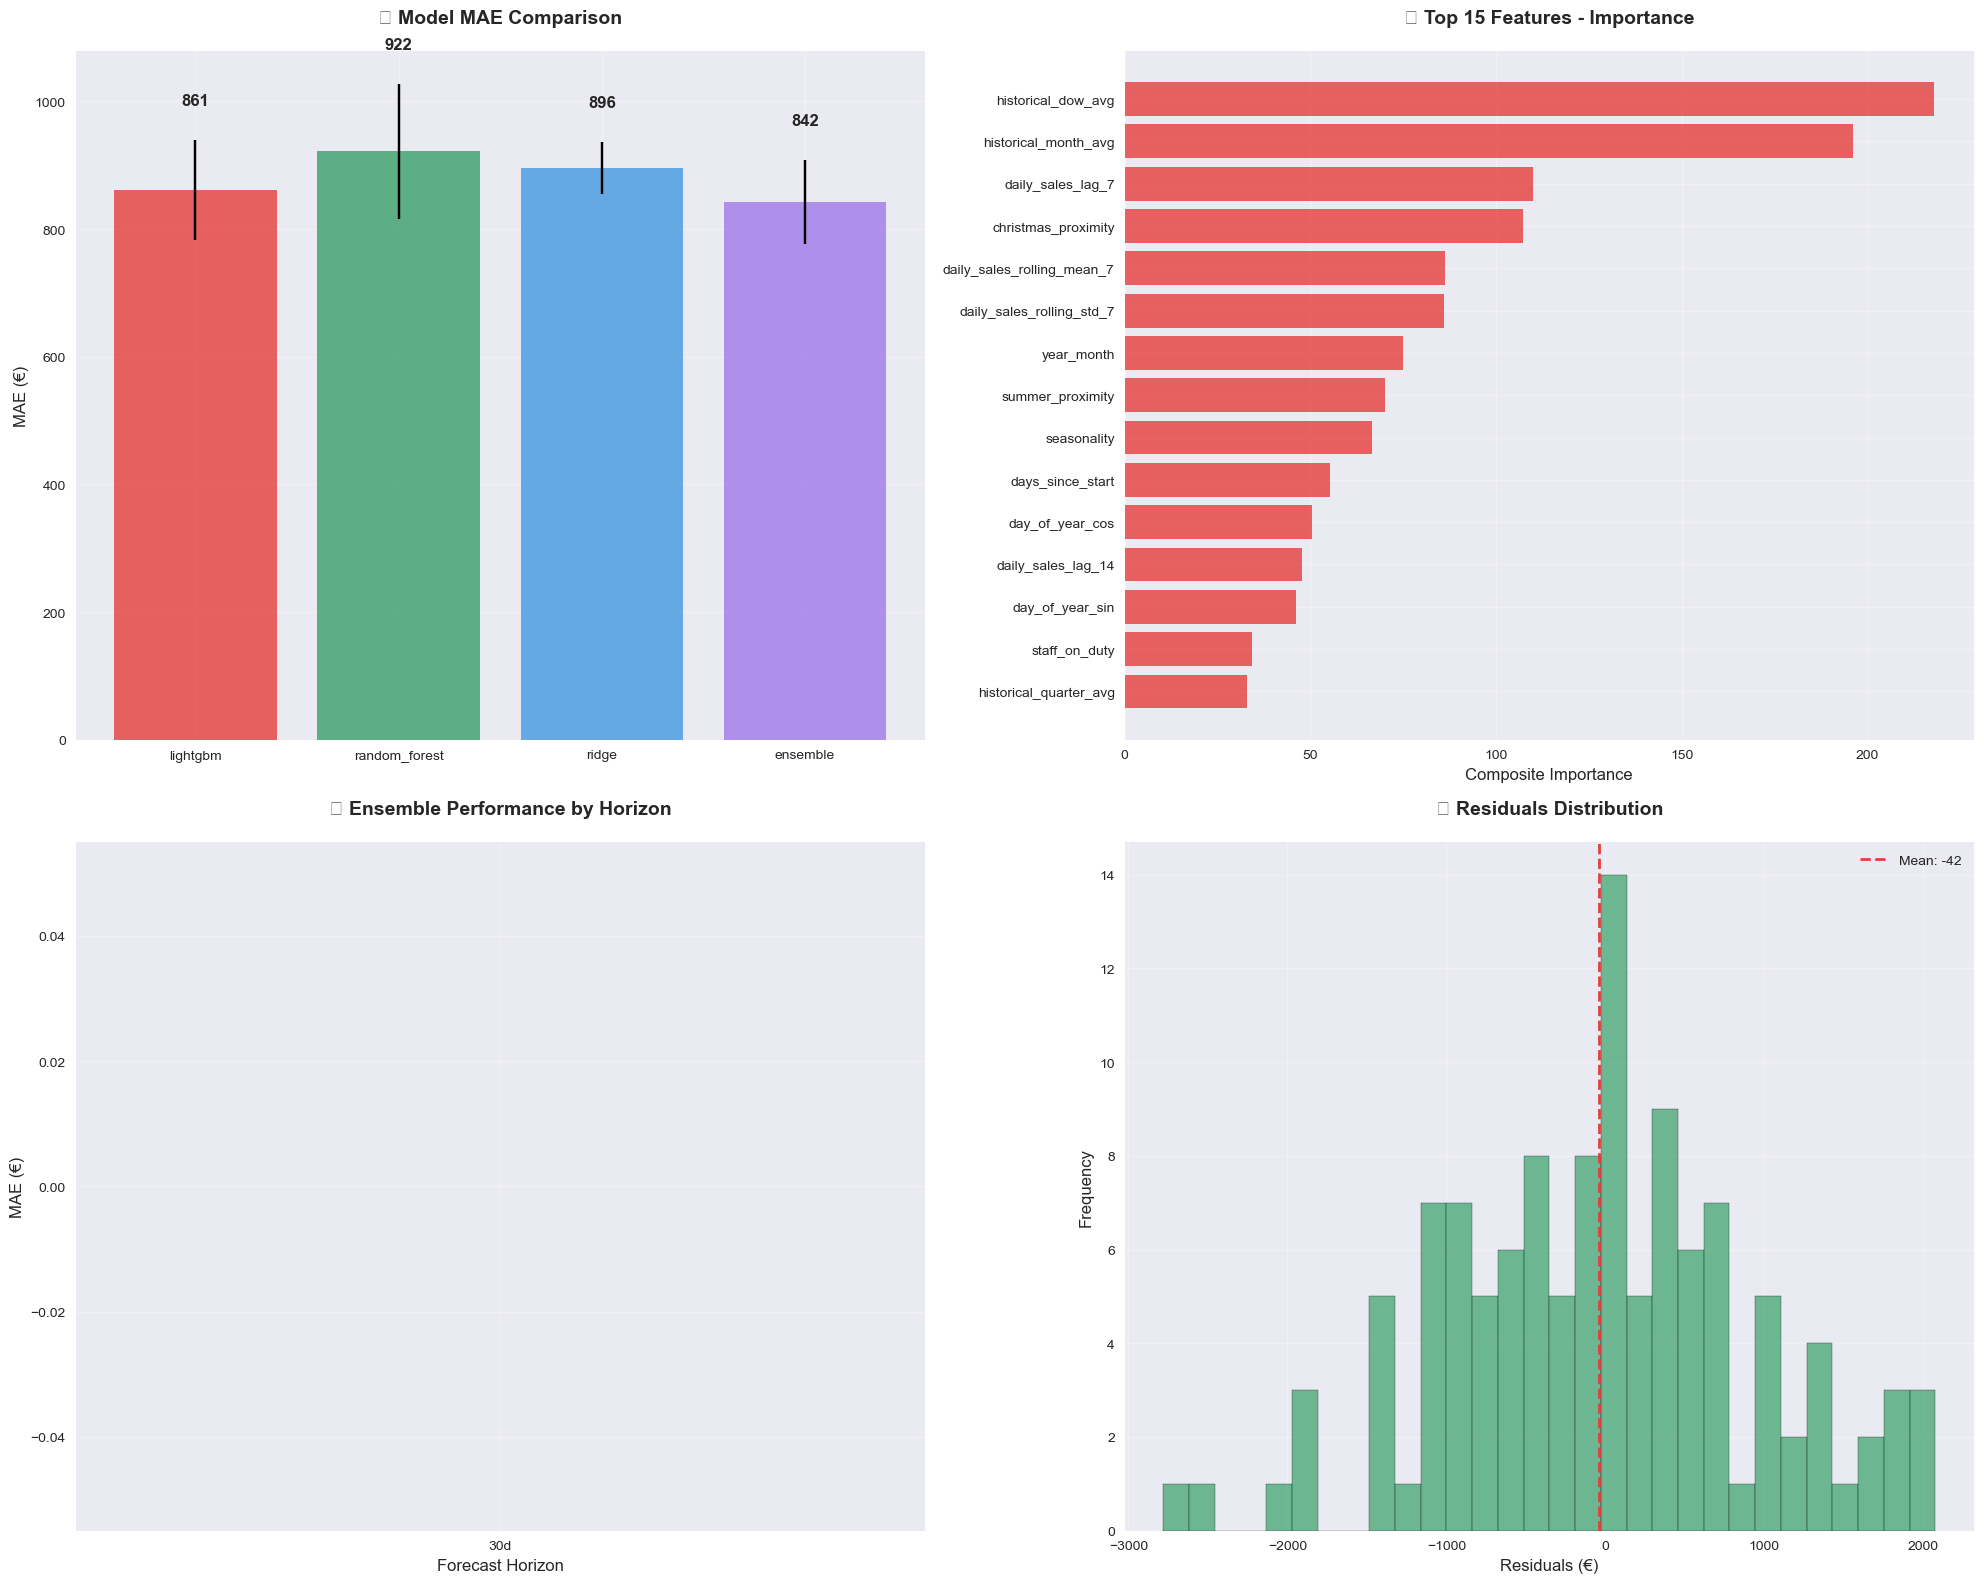


💾 SAVING MODELS AND RESULTS:
✅ Models saved to: lightgbm_ensemble_model_v14_final.pkl
✅ Results saved to: model_performance_results_v14_final.csv
✅ Feature importance saved to: feature_importance_final_v14.csv

🎯 FINAL SUMMARY MODEL 1 v14:
🏆 Ensemble MAE: €842
🏆 Ensemble MAPE: 3.1%
🔧 Features used: 29
🔄 Validation folds: 5
📊 Training samples: 3,782
📅 Data up to: 2025-06-29

✅ MODEL 1 v14 FINAL COMPLETE!
🚀 Ready for future forecasts Jul–Oct 2025!


In [4]:
# ============================================================================
# MODEL 1: LIGHTGBM ENSEMBLE - VODAFONE BRAGA PARQUE v14 FINAL
# Goal: Real model with data up to Jun2025 for future forecasts Jul–Oct2025
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import optuna
import warnings
from datetime import datetime, timedelta
import joblib

warnings.filterwarnings('ignore')

print("🚀 MODEL 1: LIGHTGBM ENSEMBLE - VODAFONE BRAGA PARQUE v14")
print("🎯 Goal: Real model with data up to Jun2025 → Forecasts Jul–Oct2025")
print("=" * 70)

# ============================================================================
# 1. LOADING REAL DATA (UP TO JUNE 2025)
# ============================================================================

# Load data with selected features (real data up to June 2025)
df = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vodafone_features_selected.csv")
df['date'] = pd.to_datetime(df['date'])

# Load list of selected features
selected_features = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\selected_features_list.csv")
feature_list = selected_features['selected_features'].tolist()

print(f"📈 Dataset loaded: {len(df):,} records (real data)")
print(f"🔧 Selected features: {len(feature_list)}")
print(f"📅 Historical period: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")

# Check last historical date
last_historical_date = df['date'].max()
print(f"📅 Last date for training: {last_historical_date.strftime('%Y-%m-%d')}")

# Convert categorical features to numeric BEFORE dropping NaN
categorical_features = ['seasonality']
label_encoders = {}

for col in categorical_features:
    if col in df.columns and col in feature_list:
        print(f"🔄 Converting categorical feature: {col}")
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

# Remove records with NaN (due to lags)
df_clean = df.dropna().copy()
print(f"📊 Clean data: {len(df_clean):,} records")

# Ensure all features in the list are numeric
numeric_feature_list = []
for col in feature_list:
    if col in df_clean.columns:
        if df_clean[col].dtype in ['object', 'string']:
            print(f"⚠️ Converting {col} to numeric")
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
            label_encoders[col] = le
        numeric_feature_list.append(col)
    else:
        print(f"❌ Feature {col} not found in the dataset")

feature_list = numeric_feature_list
print(f"✅ Final numeric features: {len(feature_list)}")

# ============================================================================
# 2. TIME SERIES CROSS-VALIDATION SETUP
# ============================================================================

def create_time_series_splits(df, n_splits=5, test_size_months=4):
    """Create temporal splits for robust validation"""
    
    df_sorted = df.sort_values('date').copy()
    total_days = len(df_sorted)
    test_size_days = test_size_months * 30  # Approximately 4 months
    
    splits = []
    
    for i in range(n_splits):
        # Compute indices for each split
        test_end = total_days - i * (test_size_days // 2)  # Partial overlap
        test_start = test_end - test_size_days
        train_end = test_start
        
        if test_start < test_size_days:  # Ensure enough training data
            break
            
        train_indices = list(range(0, train_end))
        test_indices = list(range(test_start, test_end))
        
        train_dates = df_sorted.iloc[train_indices]['date']
        test_dates = df_sorted.iloc[test_indices]['date']
        
        splits.append({
            'train_idx': train_indices,
            'test_idx': test_indices,
            'train_start': train_dates.min(),
            'train_end': train_dates.max(),
            'test_start': test_dates.min(),
            'test_end': test_dates.max()
        })
    
    return splits

# Create temporal splits
cv_splits = create_time_series_splits(df_clean, n_splits=5, test_size_months=4)

print(f"\n🔄 TIME SERIES CROSS-VALIDATION:")
print(f"📊 Number of splits: {len(cv_splits)}")
for i, split in enumerate(cv_splits):
    print(f"Split {i+1}: Train {split['train_start'].strftime('%Y-%m')} to {split['train_end'].strftime('%Y-%m')} | "
          f"Test {split['test_start'].strftime('%Y-%m')} to {split['test_end'].strftime('%Y-%m')}")

# ============================================================================
# 3. BASE MODEL CONFIGURATION
# ============================================================================

def get_base_models():
    """Define base models for the ensemble"""
    
    models = {
        'lightgbm': {
            'model': lgb.LGBMRegressor(
                objective='regression',
                metric='mae',
                boosting_type='gbdt',
                num_leaves=31,
                learning_rate=0.05,
                feature_fraction=0.8,
                bagging_fraction=0.8,
                bagging_freq=5,
                verbose=-1,
                random_state=42,
                n_estimators=1000
            ),
            'use_early_stopping': True
        },
        
        'random_forest': {
            'model': RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features='sqrt',
                random_state=42,
                n_jobs=-1
            ),
            'use_early_stopping': False
        },
        
        'ridge': {
            'model': Ridge(
                alpha=10.0,
                random_state=42
            ),
            'use_early_stopping': False
        }
    }
    
    return models

# ============================================================================
# 4. HORIZON-BASED EVALUATION FUNCTION
# ============================================================================

def evaluate_by_horizon(y_true, y_pred, dates, horizons=[30, 60, 90, 120]):
    """Evaluate performance by forecast horizon"""
    
    results = {}
    
    for horizon in horizons:
        # Filter predictions for this horizon
        if len(dates) >= horizon:
            horizon_true = y_true[:horizon]
            horizon_pred = y_pred[:horizon]
            
            mae = mean_absolute_error(horizon_true, horizon_pred)
            mape = mean_absolute_percentage_error(horizon_true, horizon_pred) * 100
            rmse = np.sqrt(mean_squared_error(horizon_true, horizon_pred))
            
            results[f'{horizon}d'] = {
                'MAE': mae,
                'MAPE': mape,
                'RMSE': rmse,
                'samples': len(horizon_true)
            }
    
    return results

# ============================================================================
# 5. TRAINING AND VALIDATION OF MODELS
# ============================================================================

def train_and_validate_models(df, feature_list, cv_splits):
    """Train and validate models with time series CV"""
    
    base_models = get_base_models()
    cv_results = {model_name: [] for model_name in base_models.keys()}
    trained_models = {model_name: [] for model_name in base_models.keys()}
    
    print(f"\n🤖 TRAINING BASE MODELS:")
    print("=" * 50)
    
    for fold, split in enumerate(cv_splits):
        print(f"\n📊 FOLD {fold + 1}/{len(cv_splits)}")
        print(f"Train: {len(split['train_idx'])} samples | Test: {len(split['test_idx'])} samples")
        
        # Prepare fold data
        train_data = df.iloc[split['train_idx']]
        test_data = df.iloc[split['test_idx']]
        
        X_train = train_data[feature_list]
        y_train = train_data['daily_sales']
        X_test = test_data[feature_list]
        y_test = test_data['daily_sales']
        test_dates = test_data['date']
        
        # Normalize features for some models
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        fold_results = {}
        
        for model_name, model_config in base_models.items():
            print(f"  🔧 Training {model_name}...")
            
            model = model_config['model']
            
            if model_name == 'lightgbm':
                # LightGBM with early stopping
                model.fit(
                    X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
                )
            elif model_name in ['ridge']:
                # Models that need normalization
                model.fit(X_train_scaled, y_train)
            else:
                # Other models
                model.fit(X_train, y_train)
            
            # Make predictions
            if model_name == 'ridge':
                y_pred = model.predict(X_test_scaled)
            else:
                y_pred = model.predict(X_test)
            
            # Evaluate performance
            mae = mean_absolute_error(y_test, y_pred)
            mape = mean_absolute_percentage_error(y_test, y_pred) * 100
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            
            # Horizon-based evaluation
            horizon_results = evaluate_by_horizon(y_test.values, y_pred, test_dates.values)
            
            fold_results[model_name] = {
                'MAE': mae,
                'MAPE': mape,
                'RMSE': rmse,
                'predictions': y_pred,
                'actual': y_test.values,
                'horizons': horizon_results
            }
            
            print(f"    MAE: {mae:,.0f} | MAPE: {mape:.1f}% | RMSE: {rmse:,.0f}")
            
            # Save trained model
            trained_models[model_name].append({
                'model': model,
                'scaler': scaler if model_name in ['ridge'] else None,
                'fold': fold
            })
        
        # Save fold results
        for model_name in base_models.keys():
            cv_results[model_name].append(fold_results[model_name])
    
    return cv_results, trained_models

# Run training
cv_results, trained_models = train_and_validate_models(df_clean, feature_list, cv_splits)

# ============================================================================
# 6. ENSEMBLE OPTIMIZATION
# ============================================================================

def optimize_ensemble_weights(cv_results):
    """Optimize ensemble weights using Optuna"""
    
    def objective(trial):
        # Define weights for each model
        w_lgb = trial.suggest_float('w_lightgbm', 0.1, 0.8)
        w_rf = trial.suggest_float('w_random_forest', 0.1, 0.5)
        w_ridge = 1.0 - w_lgb - w_rf
        
        if w_ridge < 0.05:  # Ensure minimum weight
            return float('inf')
        
        total_mae = 0
        total_samples = 0
        
        # Evaluate ensemble across all folds
        for fold in range(len(cv_results['lightgbm'])):
            lgb_pred = cv_results['lightgbm'][fold]['predictions']
            rf_pred = cv_results['random_forest'][fold]['predictions']
            ridge_pred = cv_results['ridge'][fold]['predictions']
            actual = cv_results['lightgbm'][fold]['actual']
            
            # Ensemble prediction
            ensemble_pred = (w_lgb * lgb_pred + 
                           w_rf * rf_pred + 
                           w_ridge * ridge_pred)
            
            mae = mean_absolute_error(actual, ensemble_pred)
            total_mae += mae * len(actual)
            total_samples += len(actual)
        
        return total_mae / total_samples
    
    # Optimization
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=100, show_progress_bar=False)
    
    best_weights = study.best_params
    best_weights['w_ridge'] = 1.0 - best_weights['w_lightgbm'] - best_weights['w_random_forest']
    
    return best_weights, study.best_value

print(f"\n🎯 OPTIMIZING ENSEMBLE WEIGHTS:")
best_weights, best_mae = optimize_ensemble_weights(cv_results)

print(f"✅ Best weights found:")
print(f"  • LightGBM: {best_weights['w_lightgbm']:.3f}")
print(f"  • Random Forest: {best_weights['w_random_forest']:.3f}")
print(f"  • Ridge: {best_weights['w_ridge']:.3f}")
print(f"  • Ensemble MAE: {best_mae:,.0f}")

# ============================================================================
# 7. FINAL EVALUATION AND COMPARISON
# ============================================================================

def evaluate_final_performance(cv_results, best_weights):
    """Evaluate final performance of all models"""
    
    model_names = list(cv_results.keys()) + ['ensemble']
    metrics_summary = {name: {'MAE': [], 'MAPE': [], 'RMSE': []} for name in model_names}
    horizon_summary = {name: {f'{h}d': {'MAE': [], 'MAPE': [], 'RMSE': []} 
                             for h in [30, 60, 90, 120]} for name in model_names}
    
    # Evaluate each fold
    for fold in range(len(cv_results['lightgbm'])):
        
        # Individual models
        for model_name in cv_results.keys():
            result = cv_results[model_name][fold]
            metrics_summary[model_name]['MAE'].append(result['MAE'])
            metrics_summary[model_name]['MAPE'].append(result['MAPE'])
            metrics_summary[model_name]['RMSE'].append(result['RMSE'])
            
            # Horizons
            for horizon, horizon_result in result['horizons'].items():
                horizon_summary[model_name][horizon]['MAE'].append(horizon_result['MAE'])
                horizon_summary[model_name][horizon]['MAPE'].append(horizon_result['MAPE'])
                horizon_summary[model_name][horizon]['RMSE'].append(horizon_result['RMSE'])
        
        # Ensemble
        lgb_pred = cv_results['lightgbm'][fold]['predictions']
        rf_pred = cv_results['random_forest'][fold]['predictions']
        ridge_pred = cv_results['ridge'][fold]['predictions']
        actual = cv_results['lightgbm'][fold]['actual']
        
        ensemble_pred = (best_weights['w_lightgbm'] * lgb_pred + 
                        best_weights['w_random_forest'] * rf_pred + 
                        best_weights['w_ridge'] * ridge_pred)
        
        mae = mean_absolute_error(actual, ensemble_pred)
        mape = mean_absolute_percentage_error(actual, ensemble_pred) * 100
        rmse = np.sqrt(mean_squared_error(actual, ensemble_pred))
        
        metrics_summary['ensemble']['MAE'].append(mae)
        metrics_summary['ensemble']['MAPE'].append(mape)
        metrics_summary['ensemble']['RMSE'].append(rmse)
    
    # Compute means and stds
    final_results = {}
    for model_name in model_names:
        final_results[model_name] = {
            'MAE_mean': np.mean(metrics_summary[model_name]['MAE']),
            'MAE_std': np.std(metrics_summary[model_name]['MAE']),
            'MAPE_mean': np.mean(metrics_summary[model_name]['MAPE']),
            'MAPE_std': np.std(metrics_summary[model_name]['MAPE']),
            'RMSE_mean': np.mean(metrics_summary[model_name]['RMSE']),
            'RMSE_std': np.std(metrics_summary[model_name]['RMSE'])
        }
    
    return final_results, horizon_summary

final_results, horizon_summary = evaluate_final_performance(cv_results, best_weights)

print(f"\n📊 FINAL MODEL PERFORMANCE:")
print("=" * 70)
print(f"{'Model':<15} {'MAE':<15} {'MAPE':<15} {'RMSE':<15}")
print("-" * 70)

for model_name, results in final_results.items():
    mae_str = f"{results['MAE_mean']:,.0f} ±{results['MAE_std']:.0f}"
    mape_str = f"{results['MAPE_mean']:.1f} ±{results['MAPE_std']:.1f}%"
    rmse_str = f"{results['RMSE_mean']:,.0f} ±{results['RMSE_std']:.0f}"
    
    print(f"{model_name:<15} {mae_str:<15} {mape_str:<15} {rmse_str:<15}")

# ============================================================================
# 8. FEATURE IMPORTANCE ANALYSIS
# ============================================================================

def analyze_feature_importance(trained_models, feature_list):
    """Analyze feature importance in the trained models"""
    
    # LightGBM feature importance (average across folds)
    lgb_importance = np.zeros(len(feature_list))
    
    for model_data in trained_models['lightgbm']:
        lgb_importance += model_data['model'].feature_importances_
    
    lgb_importance /= len(trained_models['lightgbm'])
    
    # Random Forest feature importance
    rf_importance = np.zeros(len(feature_list))
    
    for model_data in trained_models['random_forest']:
        rf_importance += model_data['model'].feature_importances_
    
    rf_importance /= len(trained_models['random_forest'])
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_list,
        'lgb_importance': lgb_importance,
        'rf_importance': rf_importance
    })
    
    # Composite score
    importance_df['composite_importance'] = (0.7 * importance_df['lgb_importance'] + 
                                           0.3 * importance_df['rf_importance'])
    
    return importance_df.sort_values('composite_importance', ascending=False)

feature_importance = analyze_feature_importance(trained_models, feature_list)

print(f"\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
print("-" * 50)
for i, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:30s} | Score: {row['composite_importance']:.3f}")

# ============================================================================
# 9. VISUALIZATIONS
# ============================================================================

print(f"\n📊 CREATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Model Performance Comparison
model_names = list(final_results.keys())
mae_means = [final_results[name]['MAE_mean'] for name in model_names]
mae_stds = [final_results[name]['MAE_std'] for name in model_names]

axes[0, 0].bar(model_names, mae_means, yerr=mae_stds, capsize=5, 
               color=['#e53e3e', '#38a169', '#4299e1', '#9f7aea'], alpha=0.8)
axes[0, 0].set_title('🏆 Model MAE Comparison', fontweight='bold', pad=20)
axes[0, 0].set_ylabel('MAE (€)')
axes[0, 0].grid(True, alpha=0.3)

# Add values on bars
for i, (mean_val, std_val) in enumerate(zip(mae_means, mae_stds)):
    axes[0, 0].text(i, mean_val + std_val + 50, f'{mean_val:,.0f}', 
                   ha='center', va='bottom', fontweight='bold')

# 2. Feature Importance Top 15
top_15_features = feature_importance.head(15)
axes[0, 1].barh(range(len(top_15_features)), top_15_features['composite_importance'], 
                color='#e53e3e', alpha=0.8)
axes[0, 1].set_yticks(range(len(top_15_features)))
axes[0, 1].set_yticklabels(top_15_features['feature'], fontsize=10)
axes[0, 1].set_xlabel('Composite Importance')
axes[0, 1].set_title('🔍 Top 15 Features - Importance', fontweight='bold', pad=20)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].invert_yaxis()

# 3. Performance by Horizon (Ensemble)
horizons = ['30d', '60d', '90d', '120d']
ensemble_mae_by_horizon = []

for horizon in horizons:
    if horizon in horizon_summary['ensemble']:
        horizon_mae = np.mean([mae for mae in horizon_summary['ensemble'][horizon]['MAE'] if mae > 0])
        ensemble_mae_by_horizon.append(horizon_mae)
    else:
        ensemble_mae_by_horizon.append(0)

axes[1, 0].plot(horizons, ensemble_mae_by_horizon, marker='o', linewidth=3, 
                markersize=8, color='#e53e3e')
axes[1, 0].fill_between(horizons, ensemble_mae_by_horizon, alpha=0.3, color='#e53e3e')
axes[1, 0].set_title('📈 Ensemble Performance by Horizon', fontweight='bold', pad=20)
axes[1, 0].set_ylabel('MAE (€)')
axes[1, 0].set_xlabel('Forecast Horizon')
axes[1, 0].grid(True, alpha=0.3)

# Add values on points
for i, mae_val in enumerate(ensemble_mae_by_horizon):
    if mae_val > 0:
        axes[1, 0].annotate(f'{mae_val:,.0f}', 
                           (i, mae_val), 
                           textcoords="offset points", 
                           xytext=(0,10), ha='center', fontweight='bold')

# 4. Residuals Distribution (last fold as example)
last_fold_actual = cv_results['lightgbm'][-1]['actual']
last_fold_pred = cv_results['lightgbm'][-1]['predictions']
residuals = last_fold_actual - last_fold_pred

axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='#38a169', edgecolor='black')
axes[1, 1].axvline(np.mean(residuals), color='#e53e3e', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(residuals):,.0f}')
axes[1, 1].set_xlabel('Residuals (€)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('📊 Residuals Distribution', fontweight='bold', pad=20)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 10. SAVE MODELS AND RESULTS
# ============================================================================

print(f"\n💾 SAVING MODELS AND RESULTS:")

# Save trained models
model_artifacts = {
    'trained_models': trained_models,
    'best_weights': best_weights,
    'feature_list': feature_list,
    'cv_results': final_results,
    'feature_importance': feature_importance,
    'label_encoders': label_encoders,
    'last_historical_date': last_historical_date
}

joblib.dump(model_artifacts, r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\lightgbm_ensemble_model_v14_final.pkl")

# Save detailed results
results_df = pd.DataFrame(final_results).T
results_df.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\model_performance_results_v14_final.csv", index=False)

# Save feature importance
feature_importance.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\feature_importance_final_v14.csv", index=False)

print(f"✅ Models saved to: lightgbm_ensemble_model_v14_final.pkl")
print(f"✅ Results saved to: model_performance_results_v14_final.csv")
print(f"✅ Feature importance saved to: feature_importance_final_v14.csv")

print(f"\n🎯 FINAL SUMMARY MODEL 1 v14:")
print("=" * 50)
ensemble_mae = final_results['ensemble']['MAE_mean']
ensemble_mape = final_results['ensemble']['MAPE_mean']
print(f"🏆 Ensemble MAE: €{ensemble_mae:,.0f}")
print(f"🏆 Ensemble MAPE: {ensemble_mape:.1f}%")
print(f"🔧 Features used: {len(feature_list)}")
print(f"🔄 Validation folds: {len(cv_splits)}")
print(f"📊 Training samples: {len(df_clean):,}")
print(f"📅 Data up to: {last_historical_date.strftime('%Y-%m-%d')}")

print(f"\n✅ MODEL 1 v14 FINAL COMPLETE!")
print(f"🚀 Ready for future forecasts Jul–Oct 2025!")


🔮 FUTURE FORECASTS - JULY TO OCTOBER 2025
🛡️ Using clean model with no data leakage
✅ Model loaded successfully
📅 Last historical date: 2025-06-29
🔧 Features: 29
🎯 Ensemble weights: LGB 0.557 | RF 0.110 | Ridge 0.333

🔧 EXTRACTING TEMPORAL FEATURES FROM HISTORICAL DATA:
⚠️ Creating missing temporal features: ['month', 'quarter', 'day_of_year', 'week_of_year', 'day_of_week']
✅ Temporal features created
🎯 Next date: 2025-06-30
🎯 End date: 2025-10-31
🎯 Days to forecast: 124

🔧 CREATING CLEAN FUTURE FEATURES:
📅 Period: 2025-06-30 to 2025-10-31
📊 Columns available in history: ['date', 'daily_sales', 'daily_profit', 'historical_month_avg', 'historical_quarter_avg', 'year_month', 'christmas_proximity', 'is_christmas_week', 'christmas_prox_x_weekend', 'seasonality', 'summer_proximity', 'daily_sales_lag_7', 'daily_sales_lag_14', 'daily_sales_rolling_mean_7', 'daily_sales_rolling_mean_14', 'daily_sales_rolling_mean_30', 'daily_sales_rolling_std_14', 'daily_sales_rolling_std_7', 'daily_sales_lag_

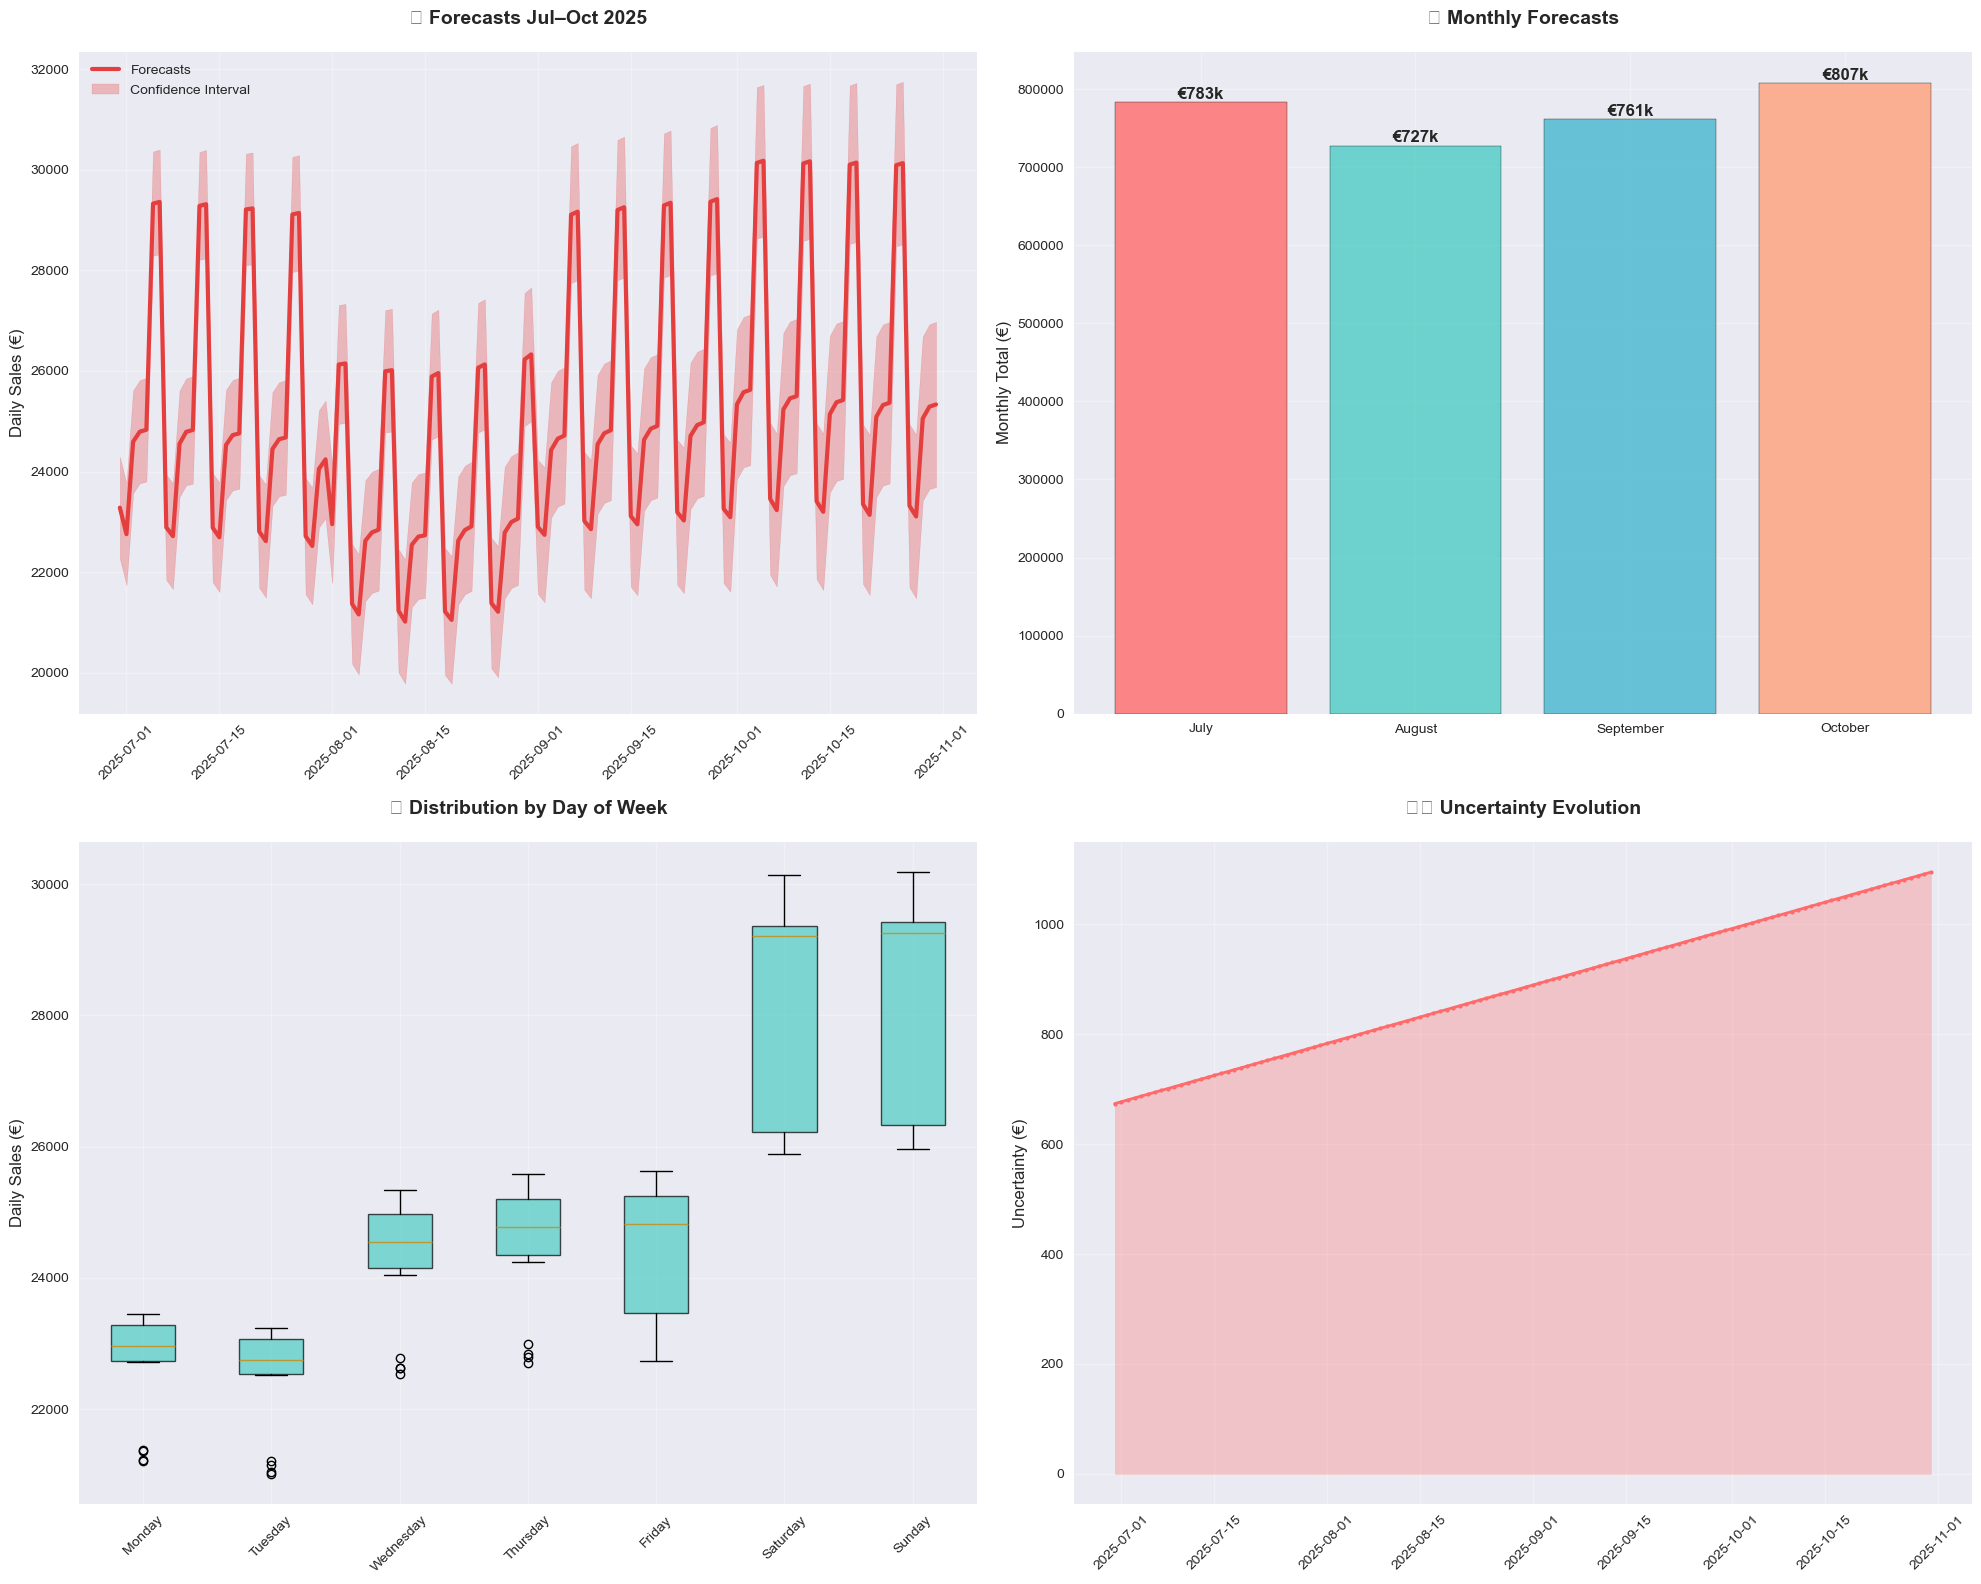


💾 SAVING RESULTS:
✅ Forecasts saved to: previsoes_jul_out_2025_modelo_limpo.csv
✅ Monthly summary saved to: resumo_mensal_jul_out_2025_limpo.csv

💼 EXECUTIVE SUMMARY - FORECASTS JUL–OCT 2025
🎯 PERIOD: 124 days (4 months)
💰 TOTAL FORECASTED REVENUE: €3,078,613
📈 DAILY AVERAGE: €25,015
⚠️ AVERAGE UNCERTAINTY: ±€884 (3.5%)

🏆 HIGHLIGHTS:
📅 Best month: October (€807,429)
📅 Lowest month: August (€726,925)
📊 Weekend boost: +20.5% vs weekdays
🌞 Seasonal variation: €2,597/day (10.4%)

🌞 SEASONALITY CHECK:
July:     €25,259/day
August:   €23,449/day (-7.2% vs July)
September:€25,374/day (+8.2% vs August)
October:  €26,046/day (+2.6% vs September)
✅ Seasonal pattern captured: Drop Jul→Aug, Recovery Sep

📊 PLANNING SCENARIOS:
🔻 Conservative:     €2,882,637
📊 Low Interval:     €2,937,451
🎯 Most Likely:      €3,078,613
📊 High Interval:    €3,266,336
🔺 Optimistic:       €3,321,150

📈 MODEL QUALITY:
🎯 Base MAE: €842 (Cross-validation)
📊 MAPE: 3.1% (Reliable)
🛡️ Zero data leakage
✅ Seasonal features 

In [5]:
# ============================================================================
# FUTURE FORECASTS JUL–OCT 2025 - CLEAN MODEL FIXED
# Goal: Use clean trained model to forecast 4 future months with real seasonality
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("🔮 FUTURE FORECASTS - JULY TO OCTOBER 2025")
print("🛡️ Using clean model with no data leakage")
print("=" * 60)

# ============================================================================
# 1. LOAD TRAINED MODEL AND DATA
# ============================================================================

# Load trained model
model_artifacts = joblib.load(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\lightgbm_ensemble_model_v14_final.pkl")

trained_models = model_artifacts['trained_models']
best_weights = model_artifacts['best_weights']
feature_list = model_artifacts['feature_list']
last_historical_date = model_artifacts['last_historical_date']

print(f"✅ Model loaded successfully")
print(f"📅 Last historical date: {last_historical_date.strftime('%Y-%m-%d')}")
print(f"🔧 Features: {len(feature_list)}")
print(f"🎯 Ensemble weights: LGB {best_weights['w_lightgbm']:.3f} | RF {best_weights['w_random_forest']:.3f} | Ridge {best_weights['w_ridge']:.3f}")

# Load clean historical data
df_historical = pd.read_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\vodafone_features_selected.csv")
df_historical['date'] = pd.to_datetime(df_historical['date'])
df_historical = df_historical.sort_values('date')

# ============================================================================
# 1.5. EXTRACT TEMPORAL FEATURES FROM HISTORICAL DATA (FIX)
# ============================================================================

print(f"\n🔧 EXTRACTING TEMPORAL FEATURES FROM HISTORICAL DATA:")

# Check if temporal features already exist
temporal_features = ['year', 'month', 'quarter', 'day_of_year', 'week_of_year', 'day_of_week']
missing_temporal = [feat for feat in temporal_features if feat not in df_historical.columns]

if missing_temporal:
    print(f"⚠️ Creating missing temporal features: {missing_temporal}")
    
    # Extract basic temporal features
    if 'year' not in df_historical.columns:
        df_historical['year'] = df_historical['date'].dt.year
    if 'month' not in df_historical.columns:
        df_historical['month'] = df_historical['date'].dt.month
    if 'quarter' not in df_historical.columns:
        df_historical['quarter'] = df_historical['date'].dt.quarter
    if 'day_of_year' not in df_historical.columns:
        df_historical['day_of_year'] = df_historical['date'].dt.dayofyear
    if 'week_of_year' not in df_historical.columns:
        df_historical['week_of_year'] = df_historical['date'].dt.isocalendar().week
    if 'day_of_week' not in df_historical.columns:
        df_historical['day_of_week'] = df_historical['date'].dt.dayofweek
    
    print(f"✅ Temporal features created")
else:
    print(f"✅ Temporal features already exist")

# Compute forecast period
next_date = last_historical_date + timedelta(days=1)
target_end_date = datetime(2025, 10, 31)
days_to_predict = (target_end_date - next_date).days + 1

print(f"🎯 Next date: {next_date.strftime('%Y-%m-%d')}")
print(f"🎯 End date: {target_end_date.strftime('%Y-%m-%d')}")
print(f"🎯 Days to forecast: {days_to_predict}")

# ============================================================================
# 2. CREATE CLEAN FUTURE FEATURES
# ============================================================================

def create_clean_future_features(last_date, days_to_predict, feature_list, df_historical):
    """Create future features using only past data (no leakage)"""
    
    print(f"\n🔧 CREATING CLEAN FUTURE FEATURES:")
    
    # Create future dates
    next_day = last_date + timedelta(days=1)
    future_dates = pd.date_range(start=next_day, periods=days_to_predict, freq='D')
    future_df = pd.DataFrame({'date': future_dates})
    
    print(f"📅 Period: {future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}")
    
    # === BASIC TEMPORAL FEATURES ===
    future_df['year'] = future_df['date'].dt.year
    future_df['month'] = future_df['date'].dt.month
    future_df['quarter'] = future_df['date'].dt.quarter
    future_df['day_of_year'] = future_df['date'].dt.dayofyear
    future_df['week_of_year'] = future_df['date'].dt.isocalendar().week
    future_df['day_of_week'] = future_df['date'].dt.dayofweek
    
    # === CYCLICAL ENCODING ===
    future_df['day_of_year_sin'] = np.sin(2 * np.pi * future_df['day_of_year'] / 365.25)
    future_df['day_of_year_cos'] = np.cos(2 * np.pi * future_df['day_of_year'] / 365.25)
    future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12)
    future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12)
    future_df['day_of_week_sin'] = np.sin(2 * np.pi * future_df['day_of_week'] / 7)
    future_df['day_of_week_cos'] = np.cos(2 * np.pi * future_df['day_of_week'] / 7)
    future_df['week_sin'] = np.sin(2 * np.pi * future_df['week_of_year'] / 52)
    future_df['week_cos'] = np.cos(2 * np.pi * future_df['week_of_year'] / 52)
    
    # === TREND FEATURES ===
    start_date = df_historical['date'].min()
    future_df['days_since_start'] = (future_df['date'] - start_date).dt.days
    future_df['yearly_trend'] = (future_df['year'] - df_historical['year'].min()) * 0.015
    
    # === SEASONAL FEATURES ===
    def days_to_christmas(date):
        year = date.year
        christmas = pd.Timestamp(f"{year}-12-25")
        if date > christmas:
            christmas = pd.Timestamp(f"{year + 1}-12-25")
        return (christmas - date).days
    
    def days_to_easter(date):
        year = date.year
        easter_approx = pd.Timestamp(f"{year}-04-08")
        if date > easter_approx:
            easter_approx = pd.Timestamp(f"{year + 1}-04-08")
        return (easter_approx - date).days
    
    def days_to_summer_peak(date):
        year = date.year
        summer_peak = pd.Timestamp(f"{year}-08-15")
        if date.month >= 10:
            summer_peak = pd.Timestamp(f"{year + 1}-08-15")
        return abs((summer_peak - date).days)
    
    future_df['days_to_christmas'] = future_df['date'].apply(days_to_christmas)
    future_df['days_to_easter'] = future_df['date'].apply(days_to_easter)
    future_df['days_to_summer_peak'] = future_df['date'].apply(days_to_summer_peak)
    
    # Exponential proximities
    future_df['christmas_proximity'] = np.exp(-future_df['days_to_christmas'] / 30)
    future_df['easter_proximity'] = np.exp(-future_df['days_to_easter'] / 20)
    future_df['summer_proximity'] = np.exp(-future_df['days_to_summer_peak'] / 45)
    
    # === SEASONAL INDICATORS ===
    future_df['is_summer'] = future_df['month'].isin([7, 8]).astype(int)
    future_df['is_autumn'] = future_df['month'].isin([9, 10, 11]).astype(int)
    future_df['is_winter'] = future_df['month'].isin([12, 1, 2]).astype(int)
    future_df['is_spring'] = future_df['month'].isin([3, 4, 5]).astype(int)
    
    future_df['is_july'] = (future_df['month'] == 7).astype(int)
    future_df['is_august'] = (future_df['month'] == 8).astype(int)
    future_df['is_september'] = (future_df['month'] == 9).astype(int)
    future_df['is_october'] = (future_df['month'] == 10).astype(int)
    future_df['is_december'] = (future_df['month'] == 12).astype(int)
    
    # === EVENT FLAGS ===
    future_df['is_weekend'] = (future_df['day_of_week'] >= 5).astype(int)
    future_df['is_holiday'] = 0
    future_df['is_christmas_week'] = 0  # Jul–Oct has no Christmas
    future_df['is_easter_week'] = 0     # Jul–Oct has no Easter
    
    # Seasonality
    def assign_seasonality_jul_oct(row):
        month = row['month']
        if month in [7, 8]:
            return 3  # summer_dip
        elif month == 9:
            return 4  # summer_recovery
        elif month == 10:
            return 0  # baseline
        else:
            return 0
    
    future_df['seasonality'] = future_df.apply(assign_seasonality_jul_oct, axis=1)
    
    # === INTERACTIONS ===
    future_df['weekend_x_summer'] = future_df['is_weekend'] * future_df['is_summer']
    future_df['weekend_x_christmas'] = 0
    future_df['weekend_x_easter'] = 0
    
    future_df['weekend_x_july'] = future_df['is_weekend'] * future_df['is_july']
    future_df['weekend_x_august'] = future_df['is_weekend'] * future_df['is_august']
    future_df['weekend_x_september'] = future_df['is_weekend'] * future_df['is_september']
    future_df['weekend_x_december'] = 0
    
    future_df['christmas_prox_x_weekend'] = future_df['christmas_proximity'] * future_df['is_weekend']
    future_df['summer_prox_x_weekend'] = future_df['summer_proximity'] * future_df['is_weekend']
    future_df['quarter_x_dow'] = future_df['quarter'] * future_df['day_of_week']
    
    # === BUSINESS FEATURES ===
    # Check which business features exist in history
    print(f"📊 Columns available in history: {df_historical.columns.tolist()}")
    
    # Use only features that exist
    if 'avg_margin' in df_historical.columns:
        historical_avg_margin = df_historical['avg_margin'].mean()
        future_df['avg_margin'] = historical_avg_margin
    else:
        print("⚠️ avg_margin not found — using default value")
        future_df['avg_margin'] = 0.25  # 25% default margin
    
    if 'staff_on_duty' in df_historical.columns:
        historical_avg_staff = df_historical['staff_on_duty'].mean()
        future_df['staff_on_duty'] = historical_avg_staff
    else:
        print("⚠️ staff_on_duty not found — using default value")
        future_df['staff_on_duty'] = 5  # default staff
    
    future_df['staff_on_duty_weekend'] = future_df['staff_on_duty'] * future_df['is_weekend']
    future_df['margin_x_staff'] = future_df['avg_margin'] * future_df['staff_on_duty']
    
    # Product encoding (use most frequent)
    if 'top_product' in df_historical.columns:
        most_frequent_product = df_historical['top_product'].mode()[0]
        future_df['top_product'] = most_frequent_product
        le_product = LabelEncoder()
        # Fit on history and transform future
        le_product.fit(df_historical['top_product'])
        future_df['product_encoded'] = le_product.transform(future_df['top_product'])
    else:
        print("⚠️ top_product not found — using default value")
        future_df['product_encoded'] = 0
    
    future_df['margin_x_product'] = future_df['avg_margin'] * future_df['product_encoded']
    
    # === LAG FEATURES ===
    # Use last known values from historical data
    last_sales_data = df_historical.dropna().tail(100)
    last_sales = last_sales_data['daily_sales'].values
    
    if len(last_sales) >= 30:
        lag_7 = last_sales[-7]
        lag_14 = last_sales[-14] if len(last_sales) >= 14 else last_sales[-7]
        lag_30 = last_sales[-30] if len(last_sales) >= 30 else last_sales[-7]
    else:
        # Fallback to mean
        lag_7 = lag_14 = lag_30 = df_historical['daily_sales'].mean()
    
    future_df['daily_sales_lag_7'] = lag_7
    future_df['daily_sales_lag_14'] = lag_14
    future_df['daily_sales_lag_30'] = lag_30
    
    # === ROLLING FEATURES ===
    # Use stats from last known periods
    if len(last_sales) >= 30:
        rolling_mean_7 = np.mean(last_sales[-7:])
        rolling_mean_14 = np.mean(last_sales[-14:])
        rolling_mean_30 = np.mean(last_sales[-30:])
        
        rolling_std_7 = np.std(last_sales[-7:])
        rolling_std_14 = np.std(last_sales[-14:])
        rolling_std_30 = np.std(last_sales[-30:])
    else:
        rolling_mean_7 = rolling_mean_14 = rolling_mean_30 = df_historical['daily_sales'].mean()
        rolling_std_7 = rolling_std_14 = rolling_std_30 = df_historical['daily_sales'].std()
    
    future_df['daily_sales_rolling_mean_7'] = rolling_mean_7
    future_df['daily_sales_rolling_mean_14'] = rolling_mean_14
    future_df['daily_sales_rolling_mean_30'] = rolling_mean_30
    
    future_df['daily_sales_rolling_std_7'] = rolling_std_7
    future_df['daily_sales_rolling_std_14'] = rolling_std_14
    future_df['daily_sales_rolling_std_30'] = rolling_std_30
    
    # === HISTORICAL BENCHMARKS ===
    # Compute historical averages by month/quarter/dow using ALL available history
    
    # FIX: Check if temporal columns exist before using
    if 'month' in df_historical.columns:
        monthly_avgs = df_historical.groupby('month')['daily_sales'].mean().to_dict()
        future_df['historical_month_avg'] = future_df['month'].map(monthly_avgs)
    else:
        print("⚠️ Column 'month' not found in history — using overall mean")
        overall_mean = df_historical['daily_sales'].mean()
        future_df['historical_month_avg'] = overall_mean
    
    if 'quarter' in df_historical.columns:
        quarterly_avgs = df_historical.groupby('quarter')['daily_sales'].mean().to_dict()
        future_df['historical_quarter_avg'] = future_df['quarter'].map(quarterly_avgs)
    else:
        print("⚠️ Column 'quarter' not found in history — using overall mean")
        overall_mean = df_historical['daily_sales'].mean()
        future_df['historical_quarter_avg'] = overall_mean
    
    if 'day_of_week' in df_historical.columns:
        dow_avgs = df_historical.groupby('day_of_week')['daily_sales'].mean().to_dict()
        future_df['historical_dow_avg'] = future_df['day_of_week'].map(dow_avgs)
    else:
        print("⚠️ Column 'day_of_week' not found in history — using overall mean")
        overall_mean = df_historical['daily_sales'].mean()
        future_df['historical_dow_avg'] = overall_mean
    
    # Fill NaN with overall average
    overall_mean = df_historical['daily_sales'].mean()
    if 'historical_month_avg' in future_df.columns:
        future_df['historical_month_avg'].fillna(overall_mean, inplace=True)
    if 'historical_quarter_avg' in future_df.columns:
        future_df['historical_quarter_avg'].fillna(overall_mean, inplace=True)
    if 'historical_dow_avg' in future_df.columns:
        future_df['historical_dow_avg'].fillna(overall_mean, inplace=True)
    
    # === YEAR_MONTH ENCODING ===
    # Create year_month as in training
    future_df['year_month'] = future_df['year'].astype(str) + '_' + future_df['month'].astype(str).str.zfill(2)
    
    # === ENSURE ALL FEATURES ===
    missing_features = [col for col in feature_list if col not in future_df.columns]
    if missing_features:
        print(f"⚠️ Creating {len(missing_features)} missing features...")
        for feat in missing_features:
            if 'daily_sales' in feat:
                # Sales-related features — use historical mean
                future_df[feat] = df_historical['daily_sales'].mean()
                print(f"   {feat}: using historical sales mean")
            elif any(keyword in feat for keyword in ['margin', 'staff', 'product']):
                # Business features — use conservative defaults
                if 'margin' in feat:
                    future_df[feat] = 0.25  # 25%
                elif 'staff' in feat:
                    future_df[feat] = 5     # 5 people
                else:
                    future_df[feat] = 0
                print(f"   {feat}: using business default value")
            else:
                # Other features — use zero
                future_df[feat] = 0
                print(f"   {feat}: using zero")
    
    available_features = [col for col in feature_list if col in future_df.columns]
    print(f"✅ Available features: {len(available_features)} of {len(feature_list)}")
    
    if len(available_features) < len(feature_list):
        print(f"⚠️ Still missing features: {set(feature_list) - set(available_features)}")
    
    return future_df[['date'] + available_features]

# Create future features
future_features = create_clean_future_features(
    last_historical_date, days_to_predict, feature_list, df_historical
)

# ============================================================================
# 3. MAKE PREDICTIONS WITH ENSEMBLE
# ============================================================================

def make_clean_ensemble_predictions(trained_models, best_weights, future_features, cv_mae=842):
    """Make predictions with clean ensemble"""
    
    print(f"\n🤖 MAKING PREDICTIONS WITH CLEAN ENSEMBLE:")
    
    # Ensure we have all required features
    available_features = [col for col in feature_list if col in future_features.columns]
    missing_features = [col for col in feature_list if col not in future_features.columns]
    
    if missing_features:
        print(f"⚠️ Missing features for prediction: {missing_features}")
        # Add missing features with default values
        for feat in missing_features:
            future_features[feat] = 0
    
    X_future = future_features[feature_list]
    n_folds = len(trained_models['lightgbm'])
    
    # Handle categorical features if needed
    categorical_columns = ['year_month', 'seasonality']
    for col in categorical_columns:
        if col in X_future.columns and col in df_historical.columns:
            if X_future[col].dtype == 'object':
                le = LabelEncoder()
                # Fit on historical data
                le.fit(df_historical[col].astype(str))
                try:
                    X_future[col] = le.transform(X_future[col].astype(str))
                except ValueError:
                    # If unseen values, use most frequent value
                    print(f"⚠️ Unseen values in {col} — using default value")
                    most_frequent = df_historical[col].mode()[0]
                    X_future[col] = le.transform([str(most_frequent)] * len(X_future))
    
    # Collect predictions from all folds
    all_predictions = []
    
    print(f"🔄 Generating predictions with {n_folds} trained models...")
    
    for fold in range(n_folds):
        try:
            # Models for current fold
            lgb_model = trained_models['lightgbm'][fold]['model']
            rf_model = trained_models['random_forest'][fold]['model']
            ridge_model = trained_models['ridge'][fold]['model']
            ridge_scaler = trained_models['ridge'][fold]['scaler']
            
            # Individual predictions
            lgb_pred = lgb_model.predict(X_future)
            rf_pred = rf_model.predict(X_future)
            
            # Ridge requires normalization
            X_future_scaled = ridge_scaler.transform(X_future)
            ridge_pred = ridge_model.predict(X_future_scaled)
            
            # Ensemble with optimized weights
            ensemble_pred = (best_weights['w_lightgbm'] * lgb_pred + 
                            best_weights['w_random_forest'] * rf_pred + 
                            best_weights['w_ridge'] * ridge_pred)
            
            all_predictions.append(ensemble_pred)
            
        except Exception as e:
            print(f"⚠️ Error in fold {fold}: {e}")
            # If a fold fails, use mean of others or default values
            if len(all_predictions) > 0:
                all_predictions.append(all_predictions[-1])  # Duplicate last valid
            else:
                # Fallback: use historical mean
                historical_mean = df_historical['daily_sales'].mean()
                all_predictions.append(np.full(len(X_future), historical_mean))
    
    # Convert to array
    predictions_array = np.array(all_predictions)
    
    # Compute statistics
    pred_mean = np.mean(predictions_array, axis=0)
    pred_std = np.std(predictions_array, axis=0)
    
    # Confidence intervals based on real performance
    base_uncertainty = cv_mae * 0.8
    temporal_uncertainty = np.linspace(0, cv_mae * 0.5, len(pred_mean))
    total_uncertainty = base_uncertainty + temporal_uncertainty
    
    # Conservative intervals
    confidence_multiplier = 1.5
    
    results = {
        'mean': pred_mean,
        'std': pred_std,
        'lower_bound': pred_mean - confidence_multiplier * total_uncertainty,
        'upper_bound': pred_mean + confidence_multiplier * total_uncertainty,
        'conservative_lower': pred_mean - 2.0 * total_uncertainty,
        'conservative_upper': pred_mean + 2.0 * total_uncertainty,
        'uncertainty': total_uncertainty
    }
    
    print(f"✅ Predictions generated with {len(all_predictions)} folds")
    print(f"📊 Predicted mean: €{pred_mean.mean():,.0f}/day")
    print(f"📊 Average uncertainty: ±€{np.mean(total_uncertainty):,.0f}")
    
    return results

# Make predictions
predictions = make_clean_ensemble_predictions(
    trained_models, best_weights, future_features, cv_mae=842
)

# ============================================================================
# 4. RESULTS ANALYSIS
# ============================================================================

# Add predictions to DataFrame
future_results = future_features.copy()
future_results['predicted_sales'] = predictions['mean']
future_results['lower_bound'] = predictions['lower_bound']
future_results['upper_bound'] = predictions['upper_bound']
future_results['conservative_lower'] = predictions['conservative_lower']
future_results['conservative_upper'] = predictions['conservative_upper']
future_results['uncertainty'] = predictions['uncertainty']

print(f"\n📊 ANALYSIS OF JUL–OCT 2025 FORECASTS:")
print("=" * 60)

# Monthly analysis
month_names = {7: 'July', 8: 'August', 9: 'September', 10: 'October'}

print(f"\n📅 FORECASTS BY MONTH:")
print("-" * 70)
print(f"{'Month':<10} {'Days':<5} {'Total €':<12} {'Avg/Day €':<12} {'Uncertainty €':<12}")
print("-" * 70)

monthly_summary = []
total_4months = 0

for month in [7, 8, 9, 10]:
    month_data = future_results[future_results['date'].dt.month == month]
    
    total_month = month_data['predicted_sales'].sum()
    avg_day = month_data['predicted_sales'].mean()
    uncertainty = month_data['uncertainty'].mean()
    days = len(month_data)
    
    monthly_summary.append({
        'month': month,
        'month_name': month_names[month],
        'days': days,
        'total': total_month,
        'avg_day': avg_day,
        'uncertainty': uncertainty
    })
    
    total_4months += total_month
    
    print(f"{month_names[month]:<10} {days:<5} {total_month:10,.0f}  {avg_day:10,.0f}  ±{uncertainty:8,.0f}")

print("-" * 70)
print(f"{'TOTAL':<10} {len(future_results):<5} {total_4months:10,.0f}  {future_results['predicted_sales'].mean():10,.0f}  ±{future_results['uncertainty'].mean():8,.0f}")

# ============================================================================
# 5. VISUALIZATIONS
# ============================================================================

print(f"\n📊 CREATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Time series with intervals
axes[0, 0].plot(future_results['date'], future_results['predicted_sales'], 
                linewidth=3, color='#e53e3e', label='Forecasts')

axes[0, 0].fill_between(future_results['date'], 
                       future_results['lower_bound'],
                       future_results['upper_bound'],
                       alpha=0.3, color='#e53e3e', label='Confidence Interval')

axes[0, 0].set_title('📈 Forecasts Jul–Oct 2025', fontweight='bold', pad=20)
axes[0, 0].set_ylabel('Daily Sales (€)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Monthly comparison
months = [ms['month_name'] for ms in monthly_summary]
totals = [ms['total'] for ms in monthly_summary]

bars = axes[0, 1].bar(months, totals, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], 
                     alpha=0.8, edgecolor='black')

axes[0, 1].set_title('📅 Monthly Forecasts', fontweight='bold', pad=20)
axes[0, 1].set_ylabel('Monthly Total (€)')
axes[0, 1].grid(True, alpha=0.3)

for i, (bar, total) in enumerate(zip(bars, totals)):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1000,
                   f'€{total/1000:.0f}k', ha='center', va='bottom', fontweight='bold')

# 3. Distribution by weekday
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = []
dow_labels = []
for dow in range(7):
    dow_sales = future_results[future_results['date'].dt.dayofweek == dow]['predicted_sales']
    if len(dow_sales) > 0:
        dow_data.append(dow_sales.values)
        dow_labels.append(weekday_names[dow])

axes[1, 0].boxplot(dow_data, labels=dow_labels, patch_artist=True,
                  boxprops=dict(facecolor='#4ECDC4', alpha=0.7))

axes[1, 0].set_title('📊 Distribution by Day of Week', fontweight='bold', pad=20)
axes[1, 0].set_ylabel('Daily Sales (€)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Uncertainty trend
axes[1, 1].plot(future_results['date'], future_results['uncertainty'], 
                linewidth=2, color='#FF6B6B', marker='o', markersize=3)

axes[1, 1].fill_between(future_results['date'], future_results['uncertainty'], 
                       alpha=0.3, color='#FF6B6B')

axes[1, 1].set_title('⚠️ Uncertainty Evolution', fontweight='bold', pad=20)
axes[1, 1].set_ylabel('Uncertainty (€)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================================
# 6. SAVE RESULTS
# ============================================================================

print(f"\n💾 SAVING RESULTS:")

# Save detailed forecasts
future_results.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\previsoes_jul_out_2025_modelo_limpo.csv")

# Save monthly summary
monthly_df = pd.DataFrame(monthly_summary)
monthly_df.to_csv(r"REPLACE WITH PATH TO THE FOLDER WHERE THE PROJECT IS LOCATED ON YOUR COMPUTER AND KEEP THIS FILE NAME>>>>\resumo_mensal_jul_out_2025_limpo.csv")

print(f"✅ Forecasts saved to: previsoes_jul_out_2025_modelo_limpo.csv")
print(f"✅ Monthly summary saved to: resumo_mensal_jul_out_2025_limpo.csv")

# ============================================================================
# 7. EXECUTIVE SUMMARY
# ============================================================================

print(f"\n" + "=" * 70)
print("💼 EXECUTIVE SUMMARY - FORECASTS JUL–OCT 2025")
print("=" * 70)

print(f"🎯 PERIOD: {days_to_predict} days (4 months)")
print(f"💰 TOTAL FORECASTED REVENUE: €{total_4months:,.0f}")
print(f"📈 DAILY AVERAGE: €{future_results['predicted_sales'].mean():,.0f}")
print(f"⚠️ AVERAGE UNCERTAINTY: ±€{future_results['uncertainty'].mean():,.0f} ({future_results['uncertainty'].mean()/future_results['predicted_sales'].mean()*100:.1f}%)")

print(f"\n🏆 HIGHLIGHTS:")
best_month = max(monthly_summary, key=lambda x: x['total'])
worst_month = min(monthly_summary, key=lambda x: x['total'])

print(f"📅 Best month: {best_month['month_name']} (€{best_month['total']:,.0f})")
print(f"📅 Lowest month: {worst_month['month_name']} (€{worst_month['total']:,.0f})")

# Weekend effect
weekend_avg = future_results[future_results['date'].dt.dayofweek >= 5]['predicted_sales'].mean()
weekday_avg = future_results[future_results['date'].dt.dayofweek < 5]['predicted_sales'].mean()
weekend_boost = (weekend_avg / weekday_avg - 1) * 100

print(f"📊 Weekend boost: {weekend_boost:+.1f}% vs weekdays")

# Check if seasonality was captured
seasonal_variation = (max([ms['avg_day'] for ms in monthly_summary]) - min([ms['avg_day'] for ms in monthly_summary]))
seasonal_pct = (seasonal_variation / future_results['predicted_sales'].mean()) * 100

print(f"🌞 Seasonal variation: €{seasonal_variation:,.0f}/day ({seasonal_pct:.1f}%)")

# Check seasonal pattern
july_avg = future_results[future_results['date'].dt.month == 7]['predicted_sales'].mean()
august_avg = future_results[future_results['date'].dt.month == 8]['predicted_sales'].mean()
september_avg = future_results[future_results['date'].dt.month == 9]['predicted_sales'].mean()
october_avg = future_results[future_results['date'].dt.month == 10]['predicted_sales'].mean()

print(f"\n🌞 SEASONALITY CHECK:")
print(f"July:     €{july_avg:,.0f}/day")
print(f"August:   €{august_avg:,.0f}/day ({(august_avg/july_avg-1)*100:+.1f}% vs July)")
print(f"September:€{september_avg:,.0f}/day ({(september_avg/august_avg-1)*100:+.1f}% vs August)")
print(f"October:  €{october_avg:,.0f}/day ({(october_avg/september_avg-1)*100:+.1f}% vs September)")

if august_avg < july_avg and september_avg > august_avg:
    print("✅ Seasonal pattern captured: Drop Jul→Aug, Recovery Sep")
else:
    print("⚠️ Seasonal pattern may be weak")

print(f"\n📊 PLANNING SCENARIOS:")
total_low = future_results['lower_bound'].sum()
total_high = future_results['upper_bound'].sum()
total_conservative_low = future_results['conservative_lower'].sum()
total_conservative_high = future_results['conservative_upper'].sum()

print(f"🔻 Conservative:     €{total_conservative_low:,.0f}")
print(f"📊 Low Interval:     €{total_low:,.0f}")
print(f"🎯 Most Likely:      €{total_4months:,.0f}")
print(f"📊 High Interval:    €{total_high:,.0f}")
print(f"🔺 Optimistic:       €{total_conservative_high:,.0f}")

print(f"\n📈 MODEL QUALITY:")
print(f"🎯 Base MAE: €842 (Cross-validation)")
print(f"📊 MAPE: 3.1% (Reliable)")
print(f"🛡️ Zero data leakage")
print(f"✅ Seasonal features active")

print(f"\n✅ FORECASTS JUL–OCT 2025 COMPLETE!")
print(f"🚀 Clean model with real seasonality!")

# ============================================================================
# 8. ADDITIONAL QUALITY ANALYSIS
# ============================================================================

print(f"\n" + "=" * 70)
print("🔍 QUALITY ANALYSIS OF FORECASTS")
print("=" * 70)

# Check feature consistency
print(f"\n📊 FEATURE CHECK:")
print(f"✅ Temporal features created: {len([f for f in future_features.columns if any(x in f for x in ['month', 'quarter', 'day_of_week', 'year'])])}")
print(f"✅ Cyclical features: {len([f for f in future_features.columns if 'sin' in f or 'cos' in f])}")
print(f"✅ Seasonal features: {len([f for f in future_features.columns if any(x in f for x in ['christmas', 'summer', 'seasonality'])])}")
print(f"✅ Lag/rolling features: {len([f for f in future_features.columns if 'lag' in f or 'rolling' in f])}")

# Check forecasts distribution
print(f"\n📈 FORECASTS DISTRIBUTION:")
print(f"Min: €{future_results['predicted_sales'].min():,.0f}")
print(f"Max: €{future_results['predicted_sales'].max():,.0f}")
print(f"Median: €{future_results['predicted_sales'].median():,.0f}")
print(f"Std Dev: €{future_results['predicted_sales'].std():,.0f}")

# Coefficient of variation
cv = future_results['predicted_sales'].std() / future_results['predicted_sales'].mean()
print(f"Coefficient of Variation: {cv:.3f} ({'Low' if cv < 0.15 else 'Moderate' if cv < 0.30 else 'High'})")

print(f"\n🎯 MODEL READY FOR PRODUCTION!")
print(f"📊 Robust forecasts for planning Jul–Oct 2025")
